# Modèle de Deep Learning : ResNet_50

Les modèles de deep learning sont entraînés directement à partir des images.

Afin de garantir une comparaison équitable avec les autres modèles de deep
learning du projet, les mêmes jeux de données sont utilisés :

- `train_augmented` pour l’entraînement ;
- `validation` pour la validation ;
- `test` pour l’évaluation finale.

Aucune nouvelle augmentation d’images ne sera appliquée dans le modèle,
puisque le jeu `train_augmented` contient déjà les images augmentées communes
aux différents modèles.

L'intégrité des données à été vérifiée dans le notebook du modèle `ResNet50` avec correction du déséquilibre.

Aucune correction supplémentaire de poids n'est réalisée ici.

# Préparation

## Environnement de travail

In [2]:
# Imports et configuration générale

from pathlib import Path
import os
import random
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    average_precision_score
)

# Graine utilisée pour améliorer la reproductibilité
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Imports réalisés avec succès.")
print("Seed :", SEED)

I0000 00:00:1785053310.997089   10077 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785053311.048283   10077 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1785053312.805253   10077 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Imports réalisés avec succès.
Seed : 42


In [3]:
# Vérification gpu

print("=" * 70)
print("Python :", sys.executable)
print("TensorFlow :", tf.__version__)

gpus = tf.config.list_physical_devices("GPU")

if not gpus:
    raise RuntimeError(
        "Aucun GPU détecté. Vérifie que le kernel sélectionné est "
        "'Python (Covid19_gpu)'."
    )

print("GPU détecté(s) :", gpus)

for gpu in gpus:
    details = tf.config.experimental.get_device_details(gpu)
    print(
        "Nom du GPU :",
        details.get("device_name", gpu.name)
    )

print("=" * 70)

Python : /home/noura/miniforge3/envs/Covid19_gpu/bin/python
TensorFlow : 2.21.0
GPU détecté(s) : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Nom du GPU : NVIDIA GeForce RTX 4090 Laptop GPU


In [4]:
# Allocation progressive de la mémoire GPU

gpus = tf.config.list_physical_devices("GPU")

for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as error:
        print(
            "La mémoire GPU a déjà été initialisée :",
            error
        )

print("Allocation progressive de la mémoire GPU configurée.")

Allocation progressive de la mémoire GPU configurée.


## Définition des chemins vers les jeux d’images

Les modèles de deep learning utilisent directement les images.

Pour garantir une comparaison équitable avec les autres modèles de l’équipe,
les jeux suivants sont utilisés :

- `train_augmented` pour l’entraînement ;
- `validation` pour la validation ;
- `test` pour l’évaluation finale.

Les chemins sont écrits au format WSL, le disque Windows `C:` étant accessible
depuis Ubuntu sous `/mnt/c/`.

In [5]:
# Dossier principal contenant les jeux d'images
DATASET_DIR = Path(
    "/mnt/c/Users/n_a_e/Documents/DataScientest/"
    "Data Scientist/Projet COVID/"
    "COVID-19_Radiography_Dataset_split"
)

# Dossiers utilisés pour ResNet
TRAIN_DIR = DATASET_DIR / "train_augmented"
VAL_DIR = DATASET_DIR / "validation"
TEST_DIR = DATASET_DIR / "test"

dataset_paths = {
    "Entraînement": TRAIN_DIR,
    "Validation": VAL_DIR,
    "Test": TEST_DIR
}

print("Dossier principal :", DATASET_DIR)
print()

for dataset_name, dataset_path in dataset_paths.items():
    print(f"{dataset_name} :")
    print(f"  Chemin : {dataset_path}")
    print(f"  Existe : {dataset_path.exists()}")
    print()

Dossier principal : /mnt/c/Users/n_a_e/Documents/DataScientest/Data Scientist/Projet COVID/COVID-19_Radiography_Dataset_split

Entraînement :
  Chemin : /mnt/c/Users/n_a_e/Documents/DataScientest/Data Scientist/Projet COVID/COVID-19_Radiography_Dataset_split/train_augmented
  Existe : True

Validation :
  Chemin : /mnt/c/Users/n_a_e/Documents/DataScientest/Data Scientist/Projet COVID/COVID-19_Radiography_Dataset_split/validation
  Existe : True

Test :
  Chemin : /mnt/c/Users/n_a_e/Documents/DataScientest/Data Scientist/Projet COVID/COVID-19_Radiography_Dataset_split/test
  Existe : True



In [14]:
missing_directories = [
    str(dataset_path)
    for dataset_path in dataset_paths.values()
    if not dataset_path.exists()
]

if missing_directories:
    raise FileNotFoundError(
        "Les dossiers suivants sont introuvables :\n"
        + "\n".join(missing_directories)
    )

print("Les trois dossiers ont été trouvés avec succès.")

Les trois dossiers ont été trouvés avec succès.


# Préparation des données

In [6]:
# Définition de l'ordre des classes

class_names = [
    "COVID",
    "Lung_Opacity",
    "Normal",
    "Viral Pneumonia"
]

NUM_CLASSES = len(class_names)

print("Classes utilisées :", class_names)

Classes utilisées : ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']


## Paramètres de chargement des images

Les images seront redimensionnées au format attendu par ResNet.

Les paramètres suivants sont communs aux jeux d’entraînement, de validation et de test afin de garantir une comparaison cohérente.

In [7]:
# Dimensions d'entrée du modèle
IMG_HEIGHT = 224
IMG_WIDTH = 224
IMG_SIZE = (IMG_HEIGHT, IMG_WIDTH)

# Taille des lots
BATCH_SIZE = 32

# Nombre de classes détectées précédemment
NUM_CLASSES = len(class_names)

print("Dimensions des images :", IMG_SIZE)
print("Taille des batchs :", BATCH_SIZE)
print("Nombre de classes :", NUM_CLASSES)

Dimensions des images : (224, 224)
Taille des batchs : 32
Nombre de classes : 4


## Création des jeux de données TensorFlow

Le jeu d’entraînement est chargé depuis le dossier `train_augmented`.

Les labels sont encodés sous forme d’entiers, ce qui permettra d’utiliser la fonction de perte `sparse_categorical_crossentropy`.

Les jeux de validation et de test sont créés avec les mêmes paramètres que le jeu d'entraînement.

Contrairement au jeu d'entraînement, les images ne sont pas mélangées (`shuffle=False`) afin de garantir un ordre stable des échantillons lors de l'évaluation finale et du calcul de la matrice de confusion.

In [8]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="int",
    class_names=class_names,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    labels="inferred",
    label_mode="int",
    class_names=class_names,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="int",
    class_names=class_names,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 33336 files belonging to 4 classes.


I0000 00:00:1785053330.369346   10077 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13512 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Found 2083 files belonging to 4 classes.
Found 2084 files belonging to 4 classes.


## Vérification d’un batch TensorFlow

Cette étape permet de contrôler la forme des tenseurs, le type des données,
la plage des valeurs de pixels et la correspondance entre les images et leurs labels.

In [18]:
images_batch, labels_batch = next(iter(train_ds))

print("Images :", images_batch.shape)
print("Labels :", labels_batch.shape)
print("Pixels :", tf.reduce_min(images_batch).numpy(),
      tf.reduce_max(images_batch).numpy())

Images : (32, 224, 224, 3)
Labels : (32,)
Pixels : 1.0 255.0


In [19]:
print("Correspondance des labels :")
print()

for class_index, class_name in enumerate(class_names):
    print(f"{class_index} -> {class_name}")

Correspondance des labels :

0 -> COVID
1 -> Lung_Opacity
2 -> Normal
3 -> Viral Pneumonia


## Optimisation du pipeline TensorFlow

Avant l'entraînement, les jeux de données sont optimisés afin d'améliorer les performances :

- application du prétraitement officiel de ResNet50 ;
- mise en cache des données (`cache()`) ;
- préchargement asynchrone (`prefetch()`).

Ces optimisations réduisent le temps d'entraînement sans modifier les données.

In [9]:
# Import du prétraitement

from tensorflow.keras.applications.resnet50 import preprocess_input

AUTOTUNE = tf.data.AUTOTUNE

In [10]:
#Fonction de prétraitement

def preprocess(image, label):
    """
    Prétraitement officiel de ResNet50.

    Les images passent d'un intervalle [0 ; 255]
    au format attendu par ResNet50.
    """
    image = preprocess_input(image)

    return image, label

In [11]:
#Pipeline optimisé

train_ds = (
    train_ds
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

val_ds = (
    val_ds
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

test_ds = (
    test_ds
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

print("Pipeline TensorFlow optimisé avec succès.")

Pipeline TensorFlow optimisé avec succès.


In [23]:
# Vérification

images, labels = next(iter(train_ds))

print(images.shape)
print(labels.shape)
print(
    "Pixels après preprocess :",
    tf.reduce_min(images).numpy(),
    tf.reduce_max(images).numpy()
)

(32, 224, 224, 3)
(32,)
Pixels après preprocess : -123.221756 151.061


# Modélisation

## Construction du modèle ResNet50

Un modèle ResNet50 pré-entraîné sur ImageNet est utilisé comme extracteur de caractéristiques.

Dans un premier temps, les couches convolutives sont gelées. Seule une nouvelle tête de classification adaptée aux quatre classes du projet sera entraînée.

In [16]:
# Téléchargement

from tensorflow.keras.applications import ResNet50

# Chargement de ResNet50 sans sa couche de classification d'origine
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
)

# Gel de toutes les couches pré-entraînées
base_model.trainable = False

print("ResNet50 chargé avec succès.")
print("Nombre total de couches :", len(base_model.layers))
print("Modèle de base entraînable :", base_model.trainable)

ResNet50 chargé avec succès.
Nombre total de couches : 175
Modèle de base entraînable : False


In [17]:
# Construction de la tête de classification

inputs = keras.Input(
    shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    name="input_image"
)

# Passage dans ResNet50
x = base_model(
    inputs,
    training=False
)

# Réduction de chaque carte de caractéristiques à une valeur moyenne
x = layers.GlobalAveragePooling2D(
    name="global_average_pooling"
)(x)

# Régularisation afin de limiter le surapprentissage
x = layers.Dropout(
    0.4,
    name="dropout"
)(x)

# Classification finale sur les quatre classes
outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    name="classification"
)(x)

model = keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="ResNet50_COVID19"
)

print("Modèle complet construit avec succès.")

Modèle complet construit avec succès.


In [18]:
# Vérification du modèle

model.summary()

Model: "ResNet50_COVID19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification (Dense)          │ (None, 4)              │         8,196 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,595,908 (90.01 MB)

 Trainable params: 8,196 (32.02 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [19]:
trainable_params = sum(
    np.prod(variable.shape)
    for variable in model.trainable_weights
)

non_trainable_params = sum(
    np.prod(variable.shape)
    for variable in model.non_trainable_weights
)

print(f"Paramètres entraînables     : {trainable_params:,}")
print(f"Paramètres non entraînables : {non_trainable_params:,}")

Paramètres entraînables     : 8,196
Paramètres non entraînables : 23,587,712


## Code de rechargement des modèles si besoin

Code_1

Dossier principal du projet au format WSL
PROJECT_DIR = Path(
    "/mnt/c/Users/n_a_e/Documents/DataScientest/"
    "Data Scientist/Projet COVID"
)

Dossier contenant les modèles sauvegardés
OUTPUT_DIR = PROJECT_DIR / "outputs_resnet50_sans_class_weight"

Meilleur modèle obtenu après la phase 1
PHASE1_MODEL_PATH = (
    OUTPUT_DIR / "resnet50_phase1_sans_class_weight_best.keras"
)

Vérification de l'existence du fichier
if not PHASE1_MODEL_PATH.exists():
    raise FileNotFoundError(
        "Le modèle de phase 1 est introuvable :\n"
        f"{PHASE1_MODEL_PATH}"
    )

Chargement du modèle complet
model = keras.models.load_model(
    PHASE1_MODEL_PATH
)

print("✅ Modèle de phase 1 chargé avec succès.")
print("Nom du modèle :", model.name)
print("Chemin :", PHASE1_MODEL_PATH)

Code_2

Récupération du modèle ResNet50 imbriqué
base_model = model.get_layer("resnet50")

print("Modèle de base :", base_model.name)
print("Nombre de couches :", len(base_model.layers))
print("Entraînable :", base_model.trainable)


## Phase 1 : Transfer Learning

### Compilation du modèle — Phase 1

Dans cette première phase, le réseau ResNet50 reste entièrement gelé.

Seule la nouvelle couche de classification est entraînée avec :

- l’optimiseur Adam ;
- un taux d’apprentissage de `1e-4` ;
- la fonction de perte `SparseCategoricalCrossentropy`, adaptée aux labels entiers ;
- l’accuracy comme métrique de suivi.

Des callbacks permettent de sauvegarder le meilleur modèle, de réduire le taux
d’apprentissage en cas de stagnation et d’arrêter l’entraînement avant le
surapprentissage.

In [13]:
# Dossier principal du projet au format WSL
PROJECT_DIR = Path(
    "/mnt/c/Users/n_a_e/Documents/DataScientest/"
    "Data Scientist/Projet COVID"
)

# Dossier contenant les résultats sans class_weight
OUTPUT_DIR = (
    PROJECT_DIR
    / "outputs_resnet50_sans_class_weight"
)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Modèles sauvegardés
PHASE1_MODEL_PATH = (
    OUTPUT_DIR
    / "resnet50_phase1_sans_class_weight_best.keras"
)

PHASE2_MODEL_PATH = (
    OUTPUT_DIR
    / "resnet50_finetuning_best.keras"
)

print("Dossier du projet :", PROJECT_DIR)
print("Dossier de sortie :", OUTPUT_DIR)
print("Modèle phase 1    :", PHASE1_MODEL_PATH)
print("Modèle fine-tuné  :", PHASE2_MODEL_PATH)

Dossier du projet : /mnt/c/Users/n_a_e/Documents/DataScientest/Data Scientist/Projet COVID
Dossier de sortie : /mnt/c/Users/n_a_e/Documents/DataScientest/Data Scientist/Projet COVID/outputs_resnet50_sans_class_weight
Modèle phase 1    : /mnt/c/Users/n_a_e/Documents/DataScientest/Data Scientist/Projet COVID/outputs_resnet50_sans_class_weight/resnet50_phase1_sans_class_weight_best.keras
Modèle fine-tuné  : /mnt/c/Users/n_a_e/Documents/DataScientest/Data Scientist/Projet COVID/outputs_resnet50_sans_class_weight/resnet50_finetuning_best.keras


In [21]:
print("\nVérification des fichiers existants :")
print(
    "Modèle phase 1 trouvé :",
    PHASE1_MODEL_PATH.exists()
)
print(
    "Modèle fine-tuné trouvé :",
    PHASE2_MODEL_PATH.exists()
)


Vérification des fichiers existants :
Modèle phase 1 trouvé : True
Modèle fine-tuné trouvé : False


In [22]:
# Compilation

LEARNING_RATE_PHASE1 = 1e-4

model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=LEARNING_RATE_PHASE1
    ),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        )
    ]
)

print("Modèle compilé avec succès.")
print("Learning rate phase 1 :", LEARNING_RATE_PHASE1)

Modèle compilé avec succès.
Learning rate phase 1 : 0.0001


In [23]:
# Définition du callback pour le suivi du F1_macro

class MacroF1Callback(tf.keras.callbacks.Callback):
    """
    Calcule le F1 macro sur les jeux d'entraînement et de validation
    à la fin de chaque époque.
    """

    def __init__(self, train_ds, val_ds):

        super().__init__()

        self.train_ds = train_ds
        self.val_ds = val_ds

    def _compute_f1(self, dataset):

        y_true = []
        y_pred = []

        for images, labels in dataset:

            predictions = self.model.predict(
                images,
                verbose=0
            )

            predictions = np.argmax(
                predictions,
                axis=1
            )

            y_true.extend(labels.numpy())
            y_pred.extend(predictions)

        return f1_score(
            y_true,
            y_pred,
            average="macro"
        )

    def on_epoch_end(self, epoch, logs=None):

        logs = logs or {}

        train_f1 = self._compute_f1(self.train_ds)
        val_f1 = self._compute_f1(self.val_ds)

        logs["f1_macro"] = train_f1
        logs["val_f1_macro"] = val_f1

        print(
            f"\nMacro F1 : "
            f"{train_f1:.4f} "
            f"- "
            f"val_macro_f1 : "
            f"{val_f1:.4f}"
        )

In [24]:
macro_f1_callback = MacroF1Callback(
    train_ds=train_ds,
    val_ds=val_ds
)

In [25]:
# Définition des callbacks

callbacks_phase1 = [

    macro_f1_callback,

    keras.callbacks.ModelCheckpoint(
        filepath=PHASE1_MODEL_PATH,
        monitor="val_f1_macro",
        mode="max",
        save_best_only=True,
        verbose=1
    ),

    keras.callbacks.EarlyStopping(
        monitor="val_f1_macro",
        mode="max",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_f1_macro",
        mode="max",
        factor=0.2,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

print("Callbacks configurés :", len(callbacks_phase1))

for callback in callbacks_phase1:
    print("-", callback.__class__.__name__)

Callbacks configurés : 4
- MacroF1Callback
- ModelCheckpoint
- EarlyStopping
- ReduceLROnPlateau


In [26]:
images, labels = next(iter(train_ds))

print(images.shape)
print(labels.shape)

(32, 224, 224, 3)
(32,)


### Entraînement de la tête de classification

Dans cette première phase, toutes les couches de ResNet50 restent gelées.

Seule la tête de classification ajoutée au modèle est entraînée pendant un maximum de 20 époques. Les poids de classes sont utilisés afin de limiter l’impact du déséquilibre entre les catégories.

In [27]:
EPOCHS_PHASE1 = 20

history_phase1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_PHASE1,
    callbacks=callbacks_phase1
)

Epoch 1/20


/home/noura/miniforge3/envs/Covid19_gpu/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1784715925.337618 1809943 service.cc:153] XLA service 0x7ae41c066be0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1784715925.337709 1809943 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4090 Laptop GPU, Compute Capability 8.9 (Driver: 12.7.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.24.0)
I0000 00:00:1784715925.610483 1809943 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1784715926.856241 1809943 cuda_dnn.cc:461] Loaded cuDNN version 92400
I0000 00:00:1784715926.918292 1809943 dot_m

   3/1042 ━━━━━━━━━━━━━━━━━━━━ 1:03 61ms/step - accuracy: 0.1250 - loss: 2.8914 

I0000 00:00:1784715932.517260 1809943 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1040/1042 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.6062 - loss: 1.0223

I0000 00:00:1784715962.655804 1809943 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_10754__.181


1042/1042 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6062 - loss: 1.0224
Macro F1 : 0.6962 - val_macro_f1 : 0.7000

Epoch 1: val_f1_macro improved from None to 0.70004, saving model to /mnt/c/Users/n_a_e/Documents/DataScientest/Data Scientist/Projet COVID/outputs_resnet50_sans_class_weight/resnet50_phase1_sans_class_weight_best.keras

Epoch 1: finished saving model to /mnt/c/Users/n_a_e/Documents/DataScientest/Data Scientist/Projet COVID/outputs_resnet50_sans_class_weight/resnet50_phase1_sans_class_weight_best.keras
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 163s 147ms/step - accuracy: 0.6062 - loss: 1.0224 - val_accuracy: 0.7571 - val_loss: 0.6200 - f1_macro: 0.6962 - val_f1_macro: 0.7000 - learning_rate: 1.0000e-04
Epoch 2/20
1041/1042 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7202 - loss: 0.7086
Macro F1 : 0.7389 - val_macro_f1 : 0.7293

Epoch 2: val_f1_macro improved from 0.70004 to 0.72931, saving model to /mnt/c/Users/n_a_e/Documents/DataScientest/Data Scientist/Projet COVID/outpu

In [28]:
epochs_completed_phase1 = len(history_phase1.history["loss"])

best_epoch_phase1 = (
    np.argmax(history_phase1.history["val_f1_macro"]) + 1
)

best_val_f1_phase1 = float(
    np.max(history_phase1.history["val_f1_macro"])
)

best_val_loss_phase1 = float(
    history_phase1.history["val_loss"][
        best_epoch_phase1 - 1
    ]
)

best_val_accuracy_phase1 = float(
    history_phase1.history["val_accuracy"][
        best_epoch_phase1 - 1
    ]
)

print("Phase 1 terminée.")
print("Nombre d'époques exécutées :", epochs_completed_phase1)
print("Meilleure époque :", best_epoch_phase1)
print(f"Meilleur val_f1_macro : {best_val_f1_phase1:.4f}")
print(f"Val_loss à la meilleure époque : {best_val_loss_phase1:.4f}")
print(
    f"Val_accuracy à la meilleure époque : "
    f"{best_val_accuracy_phase1:.4f}"
)
print("Modèle sauvegardé dans :", PHASE1_MODEL_PATH)

Phase 1 terminée.
Nombre d'époques exécutées : 18
Meilleure époque : 13
Meilleur val_f1_macro : 0.7997
Val_loss à la meilleure époque : 0.4600
Val_accuracy à la meilleure époque : 0.8190
Modèle sauvegardé dans : /mnt/c/Users/n_a_e/Documents/DataScientest/Data Scientist/Projet COVID/outputs_resnet50_sans_class_weight/resnet50_phase1_sans_class_weight_best.keras


### Analyse de l’entraînement de la phase 1

Les courbes de perte et d’accuracy permettent d’évaluer la convergence du modèle
et de détecter un éventuel surapprentissage avant le fine-tuning.

In [65]:
history_phase1_df = pd.DataFrame(
    history_phase1.history
)

history_phase1_df.index = np.arange(
    1,
    len(history_phase1_df) + 1
)

history_phase1_df.index.name = "Époque"

history_phase1_df

,accuracy,loss,val_accuracy,val_loss,f1_macro,val_f1_macro,learning_rate
Époque,,,,,,,
1,0.606192,1.022379,0.757081,0.620017,0.696237,0.700042,0.000100
2,0.720152,0.708590,0.775324,0.553671,0.738903,0.729307,0.000100
3,0.755520,0.629724,0.782045,0.534334,0.756563,0.738830,0.000100
4,0.769618,0.590706,0.795967,0.512580,0.774759,0.766257,0.000100
5,0.780568,0.567800,0.796928,0.502916,0.779819,0.764278,0.000100
6,0.787437,0.551410,0.807489,0.487342,0.787248,0.777876,0.000100
7,0.791037,0.541295,0.806529,0.482434,0.790595,0.777592,0.000100
8,0.792297,0.530937,0.807489,0.479102,0.794954,0.782095,0.000100
9,0.800426,0.522345,0.812770,0.472093,0.794220,0.783205,0.000100


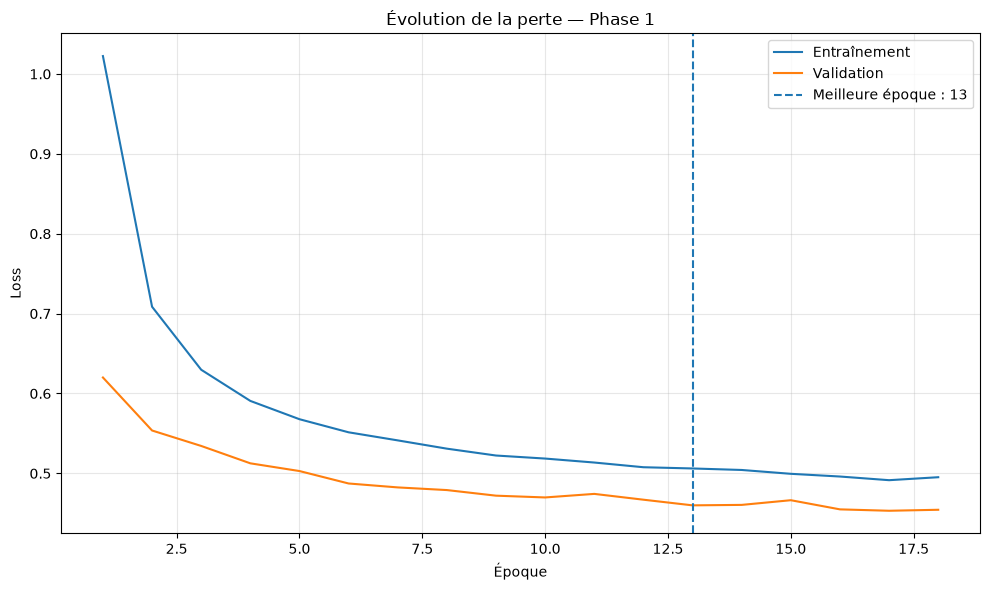

In [30]:
plt.figure(figsize=(10, 6))

plt.plot(
    history_phase1_df.index,
    history_phase1_df["loss"],
    label="Entraînement"
)

plt.plot(
    history_phase1_df.index,
    history_phase1_df["val_loss"],
    label="Validation"
)

plt.axvline(
    best_epoch_phase1,
    linestyle="--",
    label=f"Meilleure époque : {best_epoch_phase1}"
)

plt.title("Évolution de la perte — Phase 1")
plt.xlabel("Époque")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

La perte diminue rapidement puis se stabilise, avec une meilleure validation à la 13ᵉ époque. Contrairement au modèle avec class weights (meilleure époque : 17), ce modèle converge plus rapidement, tout en conservant un faible écart entre les courbes d'entraînement et de validation, signe d'un apprentissage stable.

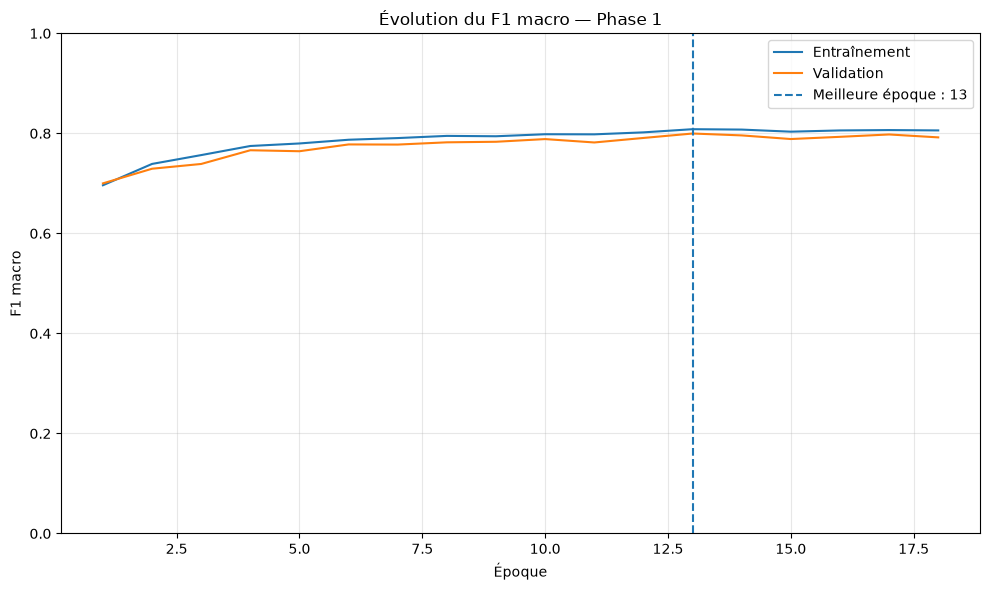

In [31]:
plt.figure(figsize=(10, 6))

plt.plot(
    history_phase1_df.index,
    history_phase1_df["f1_macro"],
    label="Entraînement"
)

plt.plot(
    history_phase1_df.index,
    history_phase1_df["val_f1_macro"],
    label="Validation"
)

plt.axvline(
    best_epoch_phase1,
    linestyle="--",
    label=f"Meilleure époque : {best_epoch_phase1}"
)

plt.title("Évolution du F1 macro — Phase 1")
plt.xlabel("Époque")
plt.ylabel("F1 macro")
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Le F1 macro augmente rapidement puis se stabilise autour de 0,80 à partir de la 13ᵉ époque, avec un très faible écart entre l'entraînement et la validation. Comme pour le modèle avec class weights, l'apprentissage est stable, mais la convergence est atteinte plus tôt (13 contre 17 époques).

In [32]:
final_train_loss = history_phase1_df["loss"].iloc[-1]
final_val_loss = history_phase1_df["val_loss"].iloc[-1]

final_train_f1 = history_phase1_df[
    "f1_macro"
].iloc[-1]

final_val_f1 = history_phase1_df[
    "val_f1_macro"
].iloc[-1]

final_train_accuracy = history_phase1_df[
    "accuracy"
].iloc[-1]

final_val_accuracy = history_phase1_df[
    "val_accuracy"
].iloc[-1]

print("Dernière époque exécutée :")
print(f"Train loss     : {final_train_loss:.4f}")
print(f"Validation loss: {final_val_loss:.4f}")
print()

print(f"Train F1 macro     : {final_train_f1:.4f}")
print(f"Validation F1 macro: {final_val_f1:.4f}")
print(
    f"Écart de F1 macro train-validation : "
    f"{final_train_f1 - final_val_f1:.4f}"
)
print()

print(f"Train accuracy     : {final_train_accuracy:.4f}")
print(f"Validation accuracy: {final_val_accuracy:.4f}")

Dernière époque exécutée :
Train loss     : 0.4952
Validation loss: 0.4544

Train F1 macro     : 0.8059
Validation F1 macro: 0.7920
Écart de F1 macro train-validation : 0.0139

Train accuracy     : 0.8086
Validation accuracy: 0.8195


### Évaluation du modèle après phase 1 sur le jeu de test

Avant le fine-tuning, le modèle obtenu à l'issue de la phase 1 est évalué
sur le jeu de test indépendant.

Cette évaluation servira de référence (baseline) pour comparer les
performances obtenues après le fine-tuning.

Les métriques calculées sont :

- Accuracy
- Balanced Accuracy
- Precision (macro)
- Recall (macro)
- F1-score (macro)
- Matrice de confusion
- Rapport de classification

In [33]:
# Chargement du meilleur modèle

best_model_phase1 = keras.models.load_model(
    PHASE1_MODEL_PATH
)

print("Meilleur modèle chargé.")

Meilleur modèle chargé.


In [34]:
# Prédiction

y_true = []
y_pred = []
y_prob = []

for images, labels in test_ds:

    probabilities = best_model_phase1.predict(
        images,
        verbose=0
    )

    predictions = np.argmax(
        probabilities,
        axis=1
    )

    y_true.extend(labels.numpy())
    y_pred.extend(predictions)
    y_prob.extend(probabilities)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

print("Nombre d'images évaluées :", len(y_true))

Nombre d'images évaluées : 2084


In [35]:
# Calcul des métriques

accuracy = accuracy_score(
    y_true,
    y_pred
)

balanced_accuracy = balanced_accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    average="macro"
)

recall = recall_score(
    y_true,
    y_pred,
    average="macro"
)

f1 = f1_score(
    y_true,
    y_pred,
    average="macro"
)

results_phase1 = pd.DataFrame({
    "Métrique": [
        "Accuracy",
        "Balanced Accuracy",
        "Precision macro",
        "Recall macro",
        "F1 macro"
    ],
    "Valeur": [
        accuracy,
        balanced_accuracy,
        precision,
        recall,
        f1
    ]
})

results_phase1

,Métrique,Valeur
0,Accuracy,0.815739
1,Balanced Accuracy,0.793816
2,Precision macro,0.812165
3,Recall macro,0.793816
4,F1 macro,0.801267


In [36]:
# Rapport de classification
print("Rapport - Phase 1:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)


Rapport - Phase 1:
                 precision    recall  f1-score   support

          COVID     0.6722    0.6024    0.6354       337
   Lung_Opacity     0.8283    0.7329    0.7777       599
         Normal     0.8371    0.9221    0.8775      1014
Viral Pneumonia     0.9111    0.9179    0.9145       134

       accuracy                         0.8157      2084
      macro avg     0.8122    0.7938    0.8013      2084
   weighted avg     0.8126    0.8157    0.8120      2084



La première phase du ResNet50 sans class weights atteint une accuracy de 81,6 % et un F1 macro de 0,801, supérieurs au modèle avec pondération (81,2 % contre 76,9 % et 0,801 contre 0,748). Les meilleures performances sont obtenues pour les classes Normal (F1 = 0,878) et Viral Pneumonia (F1 = 0,915), tandis que la classe COVID reste la plus difficile à identifier (F1 = 0,635), avec un rappel limité à 60,2 %. Le retrait des class weights améliore les performances globales, mais se fait au détriment de la détection de la classe COVID.

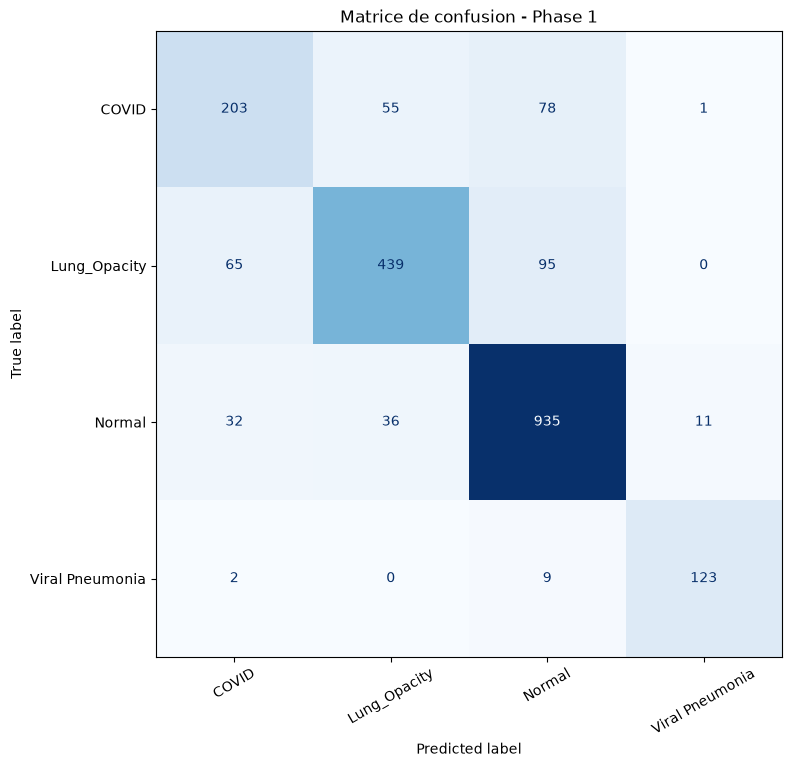

In [37]:
# Matrice de confusion

cm = confusion_matrix(
    y_true,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 8))

disp.plot(
    cmap="Blues",
    ax=ax,
    colorbar=False
)

plt.title("Matrice de confusion - Phase 1")

plt.xticks(rotation=30)

plt.tight_layout()

plt.show()

La matrice de confusion confirme ces résultats. La classe Normal est la mieux reconnue (935/1014), suivie de Viral Pneumonia (123/134). En revanche, la classe COVID est la plus difficile à identifier (203/337), avec de nombreuses confusions vers Normal (78) et Lung_Opacity (55). Par rapport au modèle avec class weights, les performances globales sont meilleures, mais la sensibilité à la classe COVID diminue.

## Phase 2 : Fine Tuning

### Péparation du fine-tuning

Le fine-tuning est réalisé uniquement sur le dernier groupe de blocs résiduels
de ResNet50, appelé `conv5_x`.

Cette stratégie permet d’adapter les caractéristiques de haut niveau au domaine
des radiographies thoraciques tout en conservant les représentations génériques
apprises dans les couches précédentes.

In [38]:
# Affichage des 50 dernières couches de ResNet50

start_index = max(0, len(base_model.layers) - 50)

for index in range(start_index, len(base_model.layers)):
    layer = base_model.layers[index]

    print(
        f"{index:>3} | "
        f"{layer.name:<35} | "
        f"{layer.__class__.__name__}"
    )

125 | conv4_block5_1_relu                 | Activation
126 | conv4_block5_2_conv                 | Conv2D
127 | conv4_block5_2_bn                   | BatchNormalization
128 | conv4_block5_2_relu                 | Activation
129 | conv4_block5_3_conv                 | Conv2D
130 | conv4_block5_3_bn                   | BatchNormalization
131 | conv4_block5_add                    | Add
132 | conv4_block5_out                    | Activation
133 | conv4_block6_1_conv                 | Conv2D
134 | conv4_block6_1_bn                   | BatchNormalization
135 | conv4_block6_1_relu                 | Activation
136 | conv4_block6_2_conv                 | Conv2D
137 | conv4_block6_2_bn                   | BatchNormalization
138 | conv4_block6_2_relu                 | Activation
139 | conv4_block6_3_conv                 | Conv2D
140 | conv4_block6_3_bn                   | BatchNormalization
141 | conv4_block6_add                    | Add
142 | conv4_block6_out                    | Activation
143 

In [39]:
# Recherche automatique du début de conv5_x

conv5_start_index = next(
    index
    for index, layer in enumerate(base_model.layers)
    if layer.name.startswith("conv5_block1")
)

print("Indice de début du bloc conv5_x :", conv5_start_index)
print(
    "Première couche du bloc :",
    base_model.layers[conv5_start_index].name
)
print(
    "Nombre de couches dans conv5_x :",
    len(base_model.layers) - conv5_start_index
)

Indice de début du bloc conv5_x : 143
Première couche du bloc : conv5_block1_1_conv
Nombre de couches dans conv5_x : 32


In [40]:
# Vérification de l’état actuel

print("État actuel avant fine-tuning :")
print("Modèle de base entraînable :", base_model.trainable)

trainable_layers_before = sum(
    layer.trainable
    for layer in base_model.layers
)

print(
    "Nombre de couches entraînables dans ResNet50 :",
    trainable_layers_before
)

État actuel avant fine-tuning :
Modèle de base entraînable : False
Nombre de couches entraînables dans ResNet50 : 0


### Déblocage du dernier bloc résiduel

Le modèle de base est rendu entraînable, mais seules les couches appartenant
au bloc `conv5_x` sont dégelées.

Les couches de normalisation par batch restent gelées afin de préserver leurs
statistiques apprises lors du pré-entraînement sur ImageNet.

In [41]:
from tensorflow.keras.layers import BatchNormalization

# Le modèle de base doit être rendu entraînable
base_model.trainable = True

for index, layer in enumerate(base_model.layers):

    # Toutes les couches situées avant conv5_x restent gelées
    if index < conv5_start_index:
        layer.trainable = False

    else:
        # Les couches BatchNormalization restent gelées
        if isinstance(layer, BatchNormalization):
            layer.trainable = False
        else:
            layer.trainable = True

print("Déblocage contrôlé terminé.")

Déblocage contrôlé terminé.


In [42]:
# Vérification des couches entraînables

trainable_layers = [
    layer.name
    for layer in base_model.layers
    if layer.trainable
]

frozen_layers = [
    layer.name
    for layer in base_model.layers
    if not layer.trainable
]

print("Nombre de couches entraînables dans ResNet50 :", len(trainable_layers))
print("Nombre de couches gelées dans ResNet50       :", len(frozen_layers))

print("\nPremières couches entraînables :")
for layer_name in trainable_layers[:10]:
    print("-", layer_name)

print("\nDernières couches entraînables :")
for layer_name in trainable_layers[-10:]:
    print("-", layer_name)

Nombre de couches entraînables dans ResNet50 : 22
Nombre de couches gelées dans ResNet50       : 153

Premières couches entraînables :
- conv5_block1_1_conv
- conv5_block1_1_relu
- conv5_block1_2_conv
- conv5_block1_2_relu
- conv5_block1_0_conv
- conv5_block1_3_conv
- conv5_block1_add
- conv5_block1_out
- conv5_block2_1_conv
- conv5_block2_1_relu

Dernières couches entraînables :
- conv5_block2_3_conv
- conv5_block2_add
- conv5_block2_out
- conv5_block3_1_conv
- conv5_block3_1_relu
- conv5_block3_2_conv
- conv5_block3_2_relu
- conv5_block3_3_conv
- conv5_block3_add
- conv5_block3_out


In [43]:
# Vérification des paramètres

trainable_params_phase2 = sum(
    np.prod(variable.shape)
    for variable in model.trainable_weights
)

non_trainable_params_phase2 = sum(
    np.prod(variable.shape)
    for variable in model.non_trainable_weights
)

print(f"Paramètres entraînables     : {trainable_params_phase2:,}")
print(f"Paramètres non entraînables : {non_trainable_params_phase2:,}")

Paramètres entraînables     : 14,961,668
Paramètres non entraînables : 8,634,240


### Compilation du modèle pour le fine-tuning

Après le déblocage du dernier bloc résiduel de ResNet50, le modèle est recompilé avec un taux d’apprentissage plus faible.

Cette précaution permet d’adapter progressivement les couches pré-entraînées aux radiographies thoraciques sans modifier brutalement les poids appris sur ImageNet.

In [44]:
LEARNING_RATE_PHASE2 = 1e-5

model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=LEARNING_RATE_PHASE2
    ),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        )
    ]
)

print("Modèle recompilé pour le fine-tuning.")
print("Learning rate phase 2 :", LEARNING_RATE_PHASE2)

Modèle recompilé pour le fine-tuning.
Learning rate phase 2 : 1e-05


In [45]:
# Callbacks du fine-tuning

PHASE2_MODEL_PATH = (
    OUTPUT_DIR / "resnet50_finetuning_best.keras"
)

callbacks_phase2 = [

    macro_f1_callback,

    keras.callbacks.ModelCheckpoint(
        filepath=PHASE2_MODEL_PATH,
        monitor="val_f1_macro",
        mode="max",
        save_best_only=True,
        verbose=1
    ),

    keras.callbacks.EarlyStopping(
        monitor="val_f1_macro",
        mode="max",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_f1_macro",
        mode="max",
        factor=0.2,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

print("Callbacks phase 2 configurés.")
print("Modèle sauvegardé dans :", PHASE2_MODEL_PATH)

Callbacks phase 2 configurés.
Modèle sauvegardé dans : /mnt/c/Users/n_a_e/Documents/DataScientest/Data Scientist/Projet COVID/outputs_resnet50_sans_class_weight/resnet50_finetuning_best.keras


In [46]:
# Vérification avant entraînement

print("État du modèle avant fine-tuning")
print("-" * 50)

print("Modèle de base entraînable :", base_model.trainable)

print(
    "Couches entraînables dans ResNet50 :",
    sum(layer.trainable for layer in base_model.layers)
)

print(
    "Paramètres entraînables du modèle complet :",
    f"{sum(np.prod(v.shape) for v in model.trainable_weights):,}"
)

print("Learning rate :", float(model.optimizer.learning_rate.numpy()))

État du modèle avant fine-tuning
--------------------------------------------------
Modèle de base entraînable : True
Couches entraînables dans ResNet50 : 22
Paramètres entraînables du modèle complet : 14,961,668
Learning rate : 9.999999747378752e-06


### Fine-tuning du modèle

Après l'entraînement de la tête de classification, les couches du bloc
`conv5_x` sont réentraînées avec un faible taux d'apprentissage (`1e-5`).

Cette seconde phase permet d'adapter les caractéristiques de haut niveau
du réseau ResNet50 au domaine des radiographies thoraciques.

In [47]:
EPOCHS_PHASE2 = 15

history_phase2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_PHASE2,
    callbacks=callbacks_phase2
)

Epoch 1/15


/home/noura/miniforge3/envs/Covid19_gpu/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1784718471.186077 1809941 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1112189__.181


1040/1042 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.8260 - loss: 0.4542

I0000 00:00:1784718516.374346 1809940 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1112189__.181


1042/1042 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8261 - loss: 0.4538
Macro F1 : 0.8614 - val_macro_f1 : 0.8334

Epoch 1: val_f1_macro improved from None to 0.83337, saving model to /mnt/c/Users/n_a_e/Documents/DataScientest/Data Scientist/Projet COVID/outputs_resnet50_sans_class_weight/resnet50_finetuning_best.keras

Epoch 1: finished saving model to /mnt/c/Users/n_a_e/Documents/DataScientest/Data Scientist/Projet COVID/outputs_resnet50_sans_class_weight/resnet50_finetuning_best.keras
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 176s 158ms/step - accuracy: 0.8261 - loss: 0.4538 - val_accuracy: 0.8459 - val_loss: 0.3919 - f1_macro: 0.8614 - val_f1_macro: 0.8334 - learning_rate: 1.0000e-05
Epoch 2/15
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8629 - loss: 0.3591
Macro F1 : 0.8964 - val_macro_f1 : 0.8539

Epoch 2: val_f1_macro improved from 0.83337 to 0.85394, saving model to /mnt/c/Users/n_a_e/Documents/DataScientest/Data Scientist/Projet COVID/outputs_resnet50_sans_class_weigh

In [48]:
best_epoch_phase2 = (
    np.argmax(history_phase2.history["val_f1_macro"]) + 1
)

best_val_f1_phase2 = float(
    np.max(history_phase2.history["val_f1_macro"])
)

best_val_loss_phase2 = float(
    history_phase2.history["val_loss"][
        best_epoch_phase2 - 1
    ]
)

best_val_accuracy_phase2 = float(
    history_phase2.history["val_accuracy"][
        best_epoch_phase2 - 1
    ]
)

print("Fine-tuning terminé.")
print("Meilleure époque :", best_epoch_phase2)
print(f"Meilleur val_f1_macro : {best_val_f1_phase2:.4f}")
print(f"Val_loss à la meilleure époque : {best_val_loss_phase2:.4f}")
print(
    f"Val_accuracy à la meilleure époque : "
    f"{best_val_accuracy_phase2:.4f}"
)

Fine-tuning terminé.
Meilleure époque : 12
Meilleur val_f1_macro : 0.8798
Val_loss à la meilleure époque : 0.8092
Val_accuracy à la meilleure époque : 0.8843


In [49]:
# Résumé de la phase 2

epochs_completed_phase2 = len(
    history_phase2.history["loss"]
)

best_epoch_phase2 = (
    np.argmax(history_phase2.history["val_f1_macro"]) + 1
)

best_val_f1_phase2 = float(
    np.max(history_phase2.history["val_f1_macro"])
)

best_val_loss_phase2 = float(
    history_phase2.history["val_loss"][
        best_epoch_phase2 - 1
    ]
)

best_val_accuracy_phase2 = float(
    history_phase2.history["val_accuracy"][
        best_epoch_phase2 - 1
    ]
)

print("Fine-tuning terminé.")
print("Nombre d'époques exécutées :", epochs_completed_phase2)
print("Meilleure époque :", best_epoch_phase2)
print(f"Meilleur val_f1_macro : {best_val_f1_phase2:.4f}")
print(f"Val_loss à la meilleure époque : {best_val_loss_phase2:.4f}")
print(
    f"Val_accuracy à la meilleure époque : "
    f"{best_val_accuracy_phase2:.4f}"
)
print("Meilleur modèle sauvegardé dans :", PHASE2_MODEL_PATH)

Fine-tuning terminé.
Nombre d'époques exécutées : 15
Meilleure époque : 12
Meilleur val_f1_macro : 0.8798
Val_loss à la meilleure époque : 0.8092
Val_accuracy à la meilleure époque : 0.8843
Meilleur modèle sauvegardé dans : /mnt/c/Users/n_a_e/Documents/DataScientest/Data Scientist/Projet COVID/outputs_resnet50_sans_class_weight/resnet50_finetuning_best.keras


In [50]:
# Bilan de la phase 2

history_phase2_df = pd.DataFrame(history_phase2.history)

history_phase2_df.index = np.arange(
    1,
    len(history_phase2_df) + 1
)

history_phase2_df.index.name = "Époque"

history_phase2_df

,accuracy,loss,val_accuracy,val_loss,f1_macro,val_f1_macro,learning_rate
Époque,,,,,,,
1,0.826134,0.453821,0.845895,0.391852,0.861356,0.833373,1.000000e-05
2,0.862851,0.359103,0.862218,0.364243,0.896380,0.853944,1.000000e-05
3,0.892909,0.286102,0.867979,0.372272,0.921443,0.856977,1.000000e-05
4,0.915107,0.227858,0.877100,0.393412,0.944010,0.868574,1.000000e-05
5,0.939015,0.166455,0.876620,0.400736,0.962869,0.871127,1.000000e-05
6,0.958453,0.116745,0.858857,0.479150,0.955490,0.854201,1.000000e-05
7,0.970122,0.081528,0.879021,0.522875,0.985710,0.876275,1.000000e-05
8,0.980532,0.056904,0.877580,0.620926,0.987683,0.875838,1.000000e-05
9,0.983201,0.045853,0.873740,0.637973,0.989843,0.872504,1.000000e-05


In [51]:
# Bilan de la phase 2

epochs_completed_phase2 = len(history_phase2_df)

best_epoch_phase2 = (
    history_phase2_df["val_f1_macro"].idxmax()
)

best_val_f1_phase2 = history_phase2_df.loc[
    best_epoch_phase2,
    "val_f1_macro"
]

best_val_loss_phase2 = history_phase2_df.loc[
    best_epoch_phase2,
    "val_loss"
]

best_val_accuracy_phase2 = history_phase2_df.loc[
    best_epoch_phase2,
    "val_accuracy"
]

final_train_loss_phase2 = history_phase2_df[
    "loss"
].iloc[-1]

final_val_loss_phase2 = history_phase2_df[
    "val_loss"
].iloc[-1]

final_train_f1_phase2 = history_phase2_df[
    "f1_macro"
].iloc[-1]

final_val_f1_phase2 = history_phase2_df[
    "val_f1_macro"
].iloc[-1]

final_train_accuracy_phase2 = history_phase2_df[
    "accuracy"
].iloc[-1]

final_val_accuracy_phase2 = history_phase2_df[
    "val_accuracy"
].iloc[-1]

print("Fine-tuning terminé.")
print("Nombre d'époques exécutées :", epochs_completed_phase2)
print("Meilleure époque :", best_epoch_phase2)
print(f"Meilleur val_f1_macro : {best_val_f1_phase2:.4f}")
print(
    f"Val_loss à la meilleure époque : "
    f"{best_val_loss_phase2:.4f}"
)
print(
    f"Val_accuracy à la meilleure époque : "
    f"{best_val_accuracy_phase2:.4f}"
)

print("\nDernière époque exécutée :")
print(f"Train loss          : {final_train_loss_phase2:.4f}")
print(f"Validation loss     : {final_val_loss_phase2:.4f}")
print(f"Train F1 macro      : {final_train_f1_phase2:.4f}")
print(f"Validation F1 macro : {final_val_f1_phase2:.4f}")
print(
    f"Écart F1 train-validation : "
    f"{final_train_f1_phase2 - final_val_f1_phase2:.4f}"
)
print(f"Train accuracy      : {final_train_accuracy_phase2:.4f}")
print(f"Validation accuracy : {final_val_accuracy_phase2:.4f}")

Fine-tuning terminé.
Nombre d'époques exécutées : 15
Meilleure époque : 12
Meilleur val_f1_macro : 0.8798
Val_loss à la meilleure époque : 0.8092
Val_accuracy à la meilleure époque : 0.8843

Dernière époque exécutée :
Train loss          : 0.0026
Validation loss     : 0.8507
Train F1 macro      : 1.0000
Validation F1 macro : 0.8767
Écart F1 train-validation : 0.1233
Train accuracy      : 0.9996
Validation accuracy : 0.8819


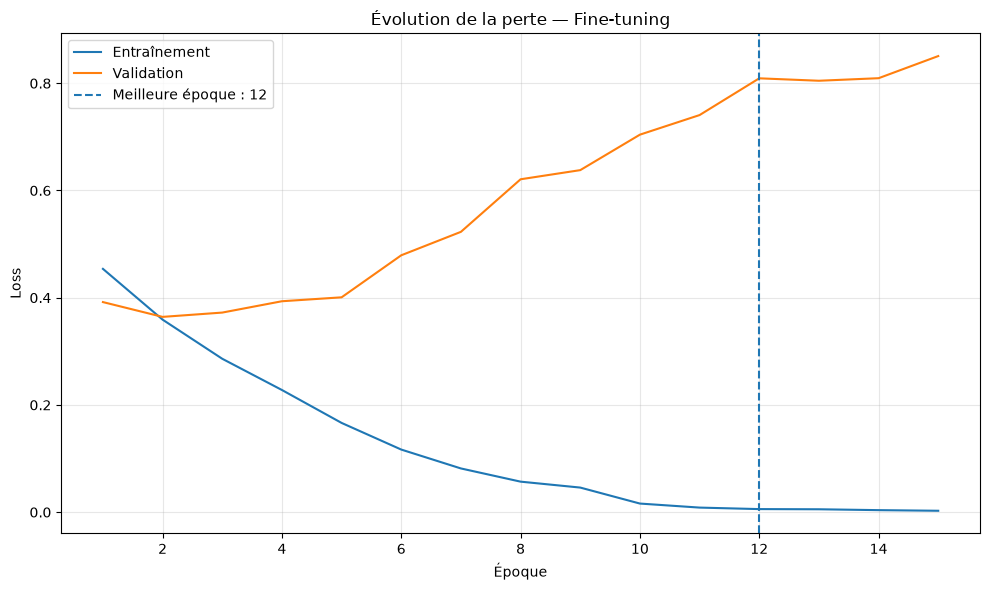

In [52]:
# Courbes de la phase 2

plt.figure(figsize=(10, 6))

plt.plot(
    history_phase2_df.index,
    history_phase2_df["loss"],
    label="Entraînement"
)

plt.plot(
    history_phase2_df.index,
    history_phase2_df["val_loss"],
    label="Validation"
)

plt.axvline(
    best_epoch_phase2,
    linestyle="--",
    label=f"Meilleure époque : {best_epoch_phase2}"
)

plt.title("Évolution de la perte — Fine-tuning")
plt.xlabel("Époque")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Dès les premières époques, la perte d'entraînement continue de diminuer alors que la perte de validation augmente progressivement. La meilleure performance est obtenue à la 12ᵉ époque, après laquelle un surapprentissage marqué apparaît. Ce phénomène est plus prononcé que pour le modèle avec class weights, qui conservait une meilleure stabilité lors du fine-tuning.

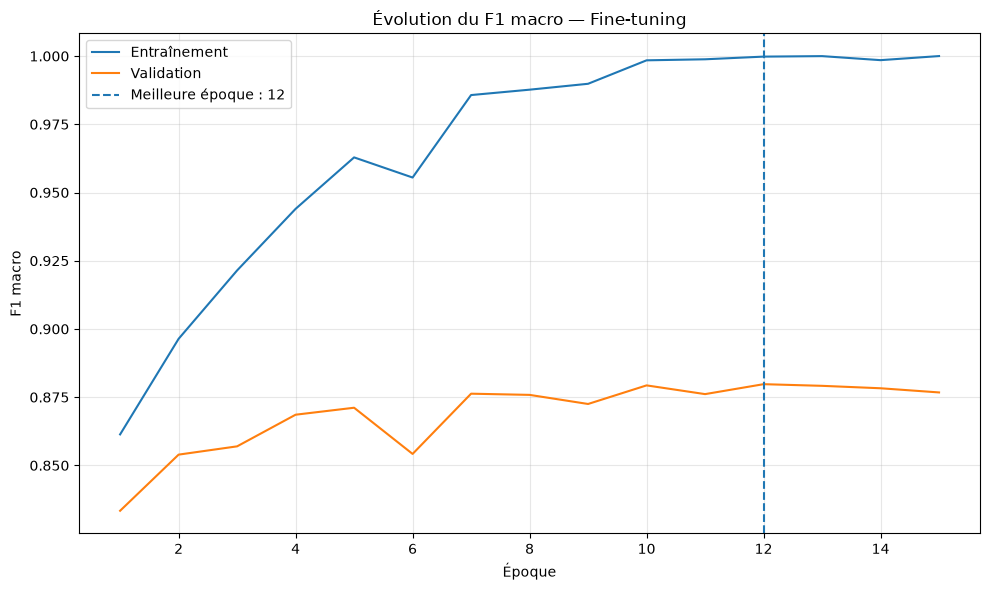

In [64]:
# Courbes de la phase 2

plt.figure(figsize=(10, 6))

plt.plot(
    history_phase2_df.index,
    history_phase2_df["f1_macro"],
    label="Entraînement"
)

plt.plot(
    history_phase2_df.index,
    history_phase2_df["val_f1_macro"],
    label="Validation"
)

plt.axvline(
    best_epoch_phase2,
    linestyle="--",
    label=f"Meilleure époque : {best_epoch_phase2}"
)

plt.title("Évolution du F1 macro — Fine-tuning")
plt.xlabel("Époque")
plt.ylabel("F1 macro")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Le F1 macro d'entraînement atteint rapidement 1,0, tandis que le F1 macro de validation plafonne autour de 0,88 dès la 10ᵉ–12ᵉ époque. Cet écart croissant confirme un surapprentissage marqué lors du fine-tuning, plus important que pour le modèle avec class weights, malgré des performances de validation légèrement supérieures.

### Évaluation finale du modèle fine-tuné

Le meilleur modèle obtenu pendant le fine-tuning est chargé depuis le fichier
de sauvegarde.

L’évaluation est ensuite réalisée sur le jeu de test indépendant, qui n’a pas
été utilisé pour entraîner le modèle ni pour sélectionner la meilleure époque.

In [14]:
# Chargement du meilleur modèle après fine-tuning

best_model_phase2 = keras.models.load_model(
    PHASE2_MODEL_PATH
)

print("Meilleur modèle fine-tuné chargé.")
print("Chemin :", PHASE2_MODEL_PATH)

Meilleur modèle fine-tuné chargé.
Chemin : /mnt/c/Users/n_a_e/Documents/DataScientest/Data Scientist/Projet COVID/outputs_resnet50_sans_class_weight/resnet50_finetuning_best.keras


In [15]:
# Vérification rapide avec evaluate
# Cette première évaluation fournit la perte et l’accuracy, mais nous allons ensuite calculer toutes les métriques détaillées.

test_loss_phase2, test_accuracy_phase2 = (
    best_model_phase2.evaluate(
        test_ds,
        verbose=1
    )
)

print("\nÉvaluation Keras sur le test :")
print(f"Test loss     : {test_loss_phase2:.4f}")
print(f"Test accuracy : {test_accuracy_phase2:.4f}")

I0000 00:00:1785053447.107270   10317 service.cc:153] XLA service 0x7cad54076e30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1785053447.107335   10317 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4090 Laptop GPU, Compute Capability 8.9 (Driver: 12.7.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.24.0)
I0000 00:00:1785053447.191182   10317 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1785053447.815826   10317 cuda_dnn.cc:461] Loaded cuDNN version 92400


 3/66 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.7708 - loss: 1.7644

I0000 00:00:1785053452.517619   10317 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


66/66 ━━━━━━━━━━━━━━━━━━━━ 11s 74ms/step - accuracy: 0.8805 - loss: 0.8235

Évaluation Keras sur le test :
Test loss     : 0.8235
Test accuracy : 0.8805


In [16]:
# Génération des prédictions

y_true_phase2 = []
y_pred_phase2 = []
y_prob_phase2 = []

for images, labels in test_ds:

    probabilities = best_model_phase2.predict(
        images,
        verbose=0
    )

    predictions = np.argmax(
        probabilities,
        axis=1
    )

    y_true_phase2.extend(labels.numpy())
    y_pred_phase2.extend(predictions)
    y_prob_phase2.extend(probabilities)

y_true_phase2 = np.array(y_true_phase2)
y_pred_phase2 = np.array(y_pred_phase2)
y_prob_phase2 = np.array(y_prob_phase2)

print("Nombre d'images évaluées :", len(y_true_phase2))
print("Forme des probabilités :", y_prob_phase2.shape)

Nombre d'images évaluées : 2084
Forme des probabilités : (2084, 4)


In [17]:
# Calcul des métriques finales

accuracy_phase2 = accuracy_score(
    y_true_phase2,
    y_pred_phase2
)

balanced_accuracy_phase2 = balanced_accuracy_score(
    y_true_phase2,
    y_pred_phase2
)

precision_phase2 = precision_score(
    y_true_phase2,
    y_pred_phase2,
    average="macro",
    zero_division=0
)

recall_phase2 = recall_score(
    y_true_phase2,
    y_pred_phase2,
    average="macro",
    zero_division=0
)

f1_phase2 = f1_score(
    y_true_phase2,
    y_pred_phase2,
    average="macro",
    zero_division=0
)

results_phase2 = pd.DataFrame({
    "Métrique": [
        "Accuracy",
        "Balanced Accuracy",
        "Precision macro",
        "Recall macro",
        "F1 macro"
    ],
    "Valeur": [
        accuracy_phase2,
        balanced_accuracy_phase2,
        precision_phase2,
        recall_phase2,
        f1_phase2
    ]
})

results_phase2

,Métrique,Valeur
0,Accuracy,0.880518
1,Balanced Accuracy,0.876166
2,Precision macro,0.876802
3,Recall macro,0.876166
4,F1 macro,0.875853


In [18]:
# Rapport de classification
print("Rapport phase_2")
print(
    classification_report(
        y_true_phase2,
        y_pred_phase2,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

Rapport phase_2
                 precision    recall  f1-score   support

          COVID     0.8382    0.7685    0.8019       337
   Lung_Opacity     0.8593    0.8464    0.8528       599
         Normal     0.9012    0.9270    0.9140      1014
Viral Pneumonia     0.9085    0.9627    0.9348       134

       accuracy                         0.8805      2084
      macro avg     0.8768    0.8762    0.8759      2084
   weighted avg     0.8795    0.8805    0.8796      2084



Après le fine-tuning, les performances atteignent 88,1 % d'accuracy et un F1 macro de 0,876, très proches de celles obtenues avec les class weights (88,0 % et 0,875). Les meilleures performances concernent les classes Normal (F1 = 0,914) et Viral Pneumonia (F1 = 0,935). La détection de la classe COVID s'améliore nettement par rapport à la première phase (F1 = 0,802 contre 0,635), montrant que le fine-tuning compense en grande partie l'absence de pondération des classes.

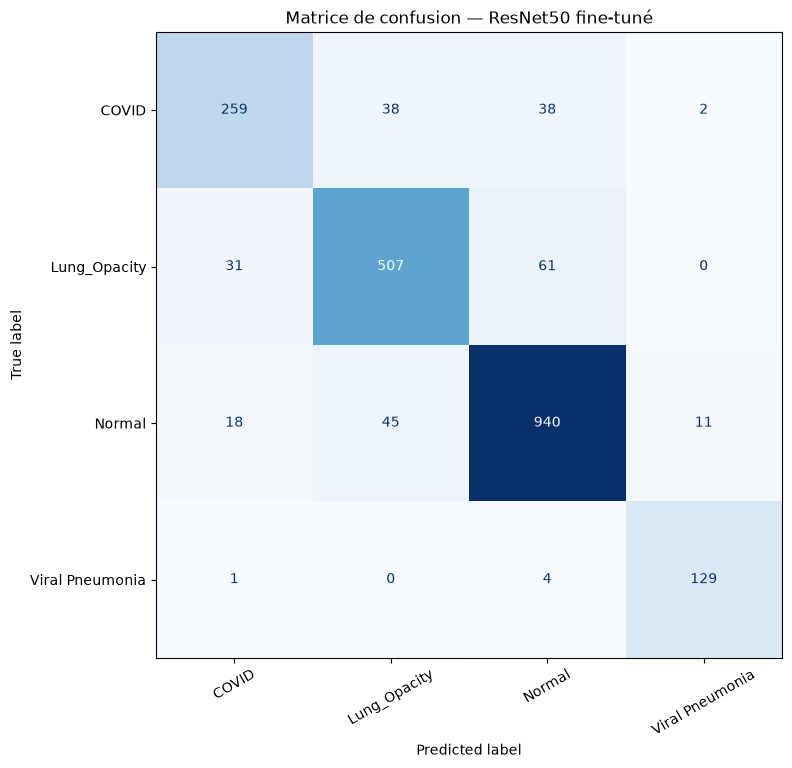

In [19]:
# Matrice de confusion

cm_phase2 = confusion_matrix(
    y_true_phase2,
    y_pred_phase2
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_phase2,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 8))

disp.plot(
    ax=ax,
    colorbar=False,
    cmap="Blues"
)

plt.title("Matrice de confusion — ResNet50 fine-tuné")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

La matrice de confusion montre une amélioration de toutes les classes après le fine-tuning. Les classes Normal (940/1014) et Viral Pneumonia (129/134) restent les mieux reconnues, tandis que la détection de COVID progresse nettement (259/337), avec moins de confusions vers Lung_Opacity (38) et Normal (38) qu'en première phase. Par rapport au modèle avec class weights, les performances sont très proches, avec un léger avantage pour Lung_Opacity, mais une sensibilité légèrement inférieure pour la classe COVID.

In [20]:
os.makedirs("predictions", exist_ok=True)
np.save("predictions/y_true_test_resnet50_unbalanced.npy", y_true_phase2)
np.save("predictions/y_prob_test_resnet50_unbalanced.npy", y_prob_phase2)
print("Sauvegardé : y_true_test_resnet50_unbalanced.npy, y_prob_test_resnet50_unbalanced.npy")

Sauvegardé : y_true_test_resnet50_unbalanced.npy, y_prob_test_resnet50_unbalanced.npy


## Interprétabilité du modèle avec Grad-CAM

Grad-CAM permet de visualiser les régions de l’image ayant le plus contribué
à la prédiction du modèle.

La carte d’activation est calculée à partir de la dernière sortie
convolutionnelle de ResNet50, puis superposée à la radiographie originale.

In [60]:
# Vérifier la couche utilisée

resnet_base = best_model_phase2.get_layer("resnet50")

print("Nom du modèle de base :", resnet_base.name)
print("Forme de sa sortie    :", resnet_base.output_shape)
print("Dernière couche       :", resnet_base.layers[-1].name)

Nom du modèle de base : resnet50
Forme de sa sortie    : (None, 7, 7, 2048)
Dernière couche       : conv5_block3_out


In [74]:
# Fonction de restauration de l’image

def deprocess_resnet50(image):
    """
    Restaure une image prétraitée avec
    tf.keras.applications.resnet50.preprocess_input
    afin de pouvoir l'afficher en RGB.
    """
    image = image.numpy().copy()

    # Réintégration des moyennes ImageNet en ordre BGR
    image[..., 0] += 103.939
    image[..., 1] += 116.779
    image[..., 2] += 123.680

    # Conversion BGR vers RGB
    image = image[..., ::-1]

    return np.clip(image, 0, 255).astype("uint8")

In [75]:
# Construction des deux sous-modèles nécessaires pour Grad-CAM

# Modèle ResNet50 imbriqué dans le modèle complet
resnet_base = best_model_phase2.get_layer("resnet50")

# Dernière couche convolutionnelle de ResNet50
LAST_CONV_LAYER_NAME = "conv5_block3_out"

last_conv_layer = resnet_base.get_layer(
    LAST_CONV_LAYER_NAME
)

# Sous-modèle :
# image -> dernière carte convolutionnelle + sortie finale de ResNet50
conv_model = keras.Model(
    inputs=resnet_base.inputs,
    outputs=[
        last_conv_layer.output,
        resnet_base.output
    ],
    name="resnet50_gradcam"
)

print("Couche Grad-CAM :", last_conv_layer.name)
print("Sortie convolutionnelle :", last_conv_layer.output.shape)
print("Sortie ResNet50 :", resnet_base.output.shape)

Couche Grad-CAM : conv5_block3_out
Sortie convolutionnelle : (None, 7, 7, 2048)
Sortie ResNet50 : (None, 7, 7, 2048)


In [76]:
# Construction des deux sous-modèles nécessaires pour Grad-CAM

# Entrée correspondant à la sortie de ResNet50
classifier_input = keras.Input(
    shape=resnet_base.output_shape[1:],
    name="classifier_input"
)

x = classifier_input

# Application des couches situées après ResNet50
resnet_layer_index = best_model_phase2.layers.index(
    resnet_base
)

for layer in best_model_phase2.layers[
    resnet_layer_index + 1:
]:
    x = layer(x)

classifier_model = keras.Model(
    inputs=classifier_input,
    outputs=x,
    name="classification_head"
)

classifier_model.summary()

Model: "classification_head"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ classifier_input (InputLayer)   │ (None, 7, 7, 2048)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification (Dense)          │ (None, 4)              │         8,196 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,196 (32.02 KB)

 Trainable params: 8,196 (32.02 KB)

 Non-trainable params: 0 (0.00 B)

In [77]:
# fonction Grad-CAM

def make_gradcam_heatmap(
    image_batch,
    conv_model,
    classifier_model,
    class_index=None
):
    """
    Calcule une carte Grad-CAM pour le modèle ResNet50 imbriqué.
    """

    with tf.GradientTape() as tape:

        # Cartes convolutives et sortie finale du ResNet50
        conv_outputs, resnet_features = conv_model(
            image_batch,
            training=False
        )

        # Nécessaire pour calculer le gradient par rapport aux activations
        tape.watch(conv_outputs)

        # Passage dans la tête de classification
        predictions = classifier_model(
            resnet_features,
            training=False
        )

        if class_index is None:
            class_index = tf.argmax(
                predictions[0]
            )

        class_score = predictions[
            :,
            class_index
        ]

    gradients = tape.gradient(
        class_score,
        conv_outputs
    )

    if gradients is None:
        raise RuntimeError(
            "Les gradients n'ont pas pu être calculés."
        )

    # Importance moyenne de chaque canal
    channel_weights = tf.reduce_mean(
        gradients,
        axis=(0, 1, 2)
    )

    feature_maps = conv_outputs[0]

    # Somme pondérée des cartes d'activation
    heatmap = tf.reduce_sum(
        feature_maps * channel_weights,
        axis=-1
    )

    # Grad-CAM conserve les contributions positives
    heatmap = tf.nn.relu(heatmap)

    # Normalisation entre 0 et 1
    max_value = tf.reduce_max(heatmap)

    if max_value > 0:
        heatmap = heatmap / max_value

    return (
        heatmap.numpy(),
        predictions[0].numpy(),
        int(class_index.numpy())
    )

In [78]:
# Fonction de superposition

def overlay_gradcam(
    original_image,
    heatmap,
    alpha=0.4
):
    """
    Superpose une carte Grad-CAM à l'image originale.
    """

    heatmap_resized = tf.image.resize(
        heatmap[..., np.newaxis],
        size=original_image.shape[:2]
    ).numpy().squeeze()

    # Transformation de la heatmap en image colorée
    colored_heatmap = plt.get_cmap("jet")(
        heatmap_resized
    )[..., :3]

    colored_heatmap = (
        colored_heatmap * 255
    ).astype("uint8")

    superimposed_image = (
        (1 - alpha) * original_image
        + alpha * colored_heatmap
    )

    return np.clip(
        superimposed_image,
        0,
        255
    ).astype("uint8")

In [79]:
def display_gradcam_grid(
    dataset,
    model,
    conv_model,
    classifier_model,
    class_names,
    n_images=12,
    only_errors=False
):
    """
    Affiche plusieurs images avec leur Grad-CAM.

    Parameters
    ----------
    dataset : tf.data.Dataset
        Dataset prétraité pour ResNet50.
    model : keras.Model
        Modèle complet fine-tuné.
    conv_model : keras.Model
        Sous-modèle fournissant les activations convolutionnelles.
    classifier_model : keras.Model
        Tête de classification.
    class_names : list[str]
        Noms des classes.
    n_images : int
        Nombre maximal d'images à afficher.
    only_errors : bool
        Si True, affiche uniquement les prédictions incorrectes.
    """

    selected = []

    for images_batch, labels_batch in dataset:

        probabilities_batch = model.predict(
            images_batch,
            verbose=0
        )

        predictions_batch = np.argmax(
            probabilities_batch,
            axis=1
        )

        for image_tensor, true_label, pred_label, probabilities in zip(
            images_batch,
            labels_batch.numpy(),
            predictions_batch,
            probabilities_batch
        ):
            is_error = int(true_label) != int(pred_label)

            if only_errors and not is_error:
                continue

            selected.append({
                "image_tensor": image_tensor,
                "true_label": int(true_label),
                "pred_label": int(pred_label),
                "probabilities": probabilities
            })

            if len(selected) >= n_images:
                break

        if len(selected) >= n_images:
            break

    if not selected:
        print("Aucune image correspondant au critère.")
        return

    fig, axes = plt.subplots(
        len(selected),
        2,
        figsize=(10, 4 * len(selected))
    )

    if len(selected) == 1:
        axes = np.array([axes])

    for row, item in enumerate(selected):

        image_tensor = item["image_tensor"]
        true_label = item["true_label"]
        pred_label = item["pred_label"]
        probabilities = item["probabilities"]

        image_batch = tf.expand_dims(
            image_tensor,
            axis=0
        )

        heatmap, _, predicted_class_index = (
            make_gradcam_heatmap(
                image_batch=image_batch,
                conv_model=conv_model,
                classifier_model=classifier_model
            )
        )

        original_image = deprocess_resnet50(
            image_tensor
        )

        gradcam_image = overlay_gradcam(
            original_image,
            heatmap,
            alpha=0.4
        )

        confidence = float(
            probabilities[predicted_class_index]
        )

        true_name = class_names[true_label]
        pred_name = class_names[pred_label]

        status = (
            "Correct"
            if true_label == pred_label
            else "Erreur"
        )

        axes[row, 0].imshow(original_image)
        axes[row, 0].set_title(
            f"Image originale\n"
            f"Classe réelle : {true_name}"
        )
        axes[row, 0].axis("off")

        axes[row, 1].imshow(gradcam_image)
        axes[row, 1].set_title(
            f"{status}\n"
            f"Prédiction : {pred_name}\n"
            f"Confiance : {confidence:.1%}"
        )
        axes[row, 1].axis("off")

    plt.tight_layout()
    plt.show()

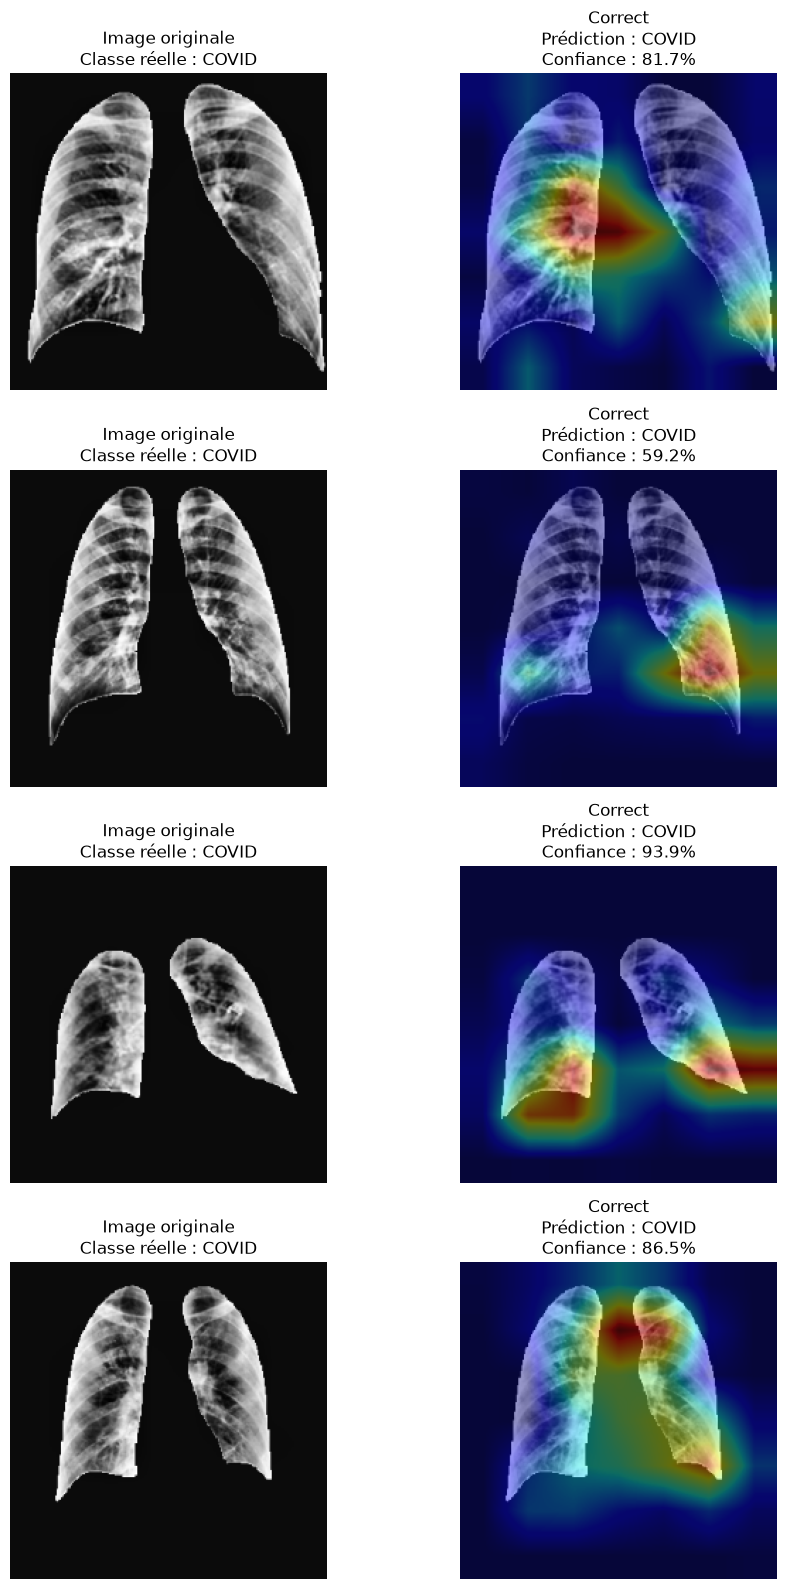

In [80]:
display_gradcam_grid(
    dataset=test_ds,
    model=best_model_phase2,
    conv_model=conv_model,
    classifier_model=classifier_model,
    class_names=class_names,
    n_images=4,
    only_errors=False
)

Les cartes Grad-CAM montrent que le modèle se concentre principalement sur les zones pulmonaires présentant des anomalies, avec des activations cohérentes sur les régions pathologiques. Les zones d'intérêt sont proches de celles obtenues avec les class weights, avec des activations légèrement plus focalisées.

# Conclusion

## Synthèse

Cette section rassemble l'ensemble des résultats obtenus avec le modèle
fine-tuné.

Les performances sont évaluées à l'aide de plusieurs métriques adaptées
à un problème de classification multiclasse déséquilibré :

- Accuracy
- Balanced Accuracy
- Precision macro
- Recall macro
- F1-score macro

Les résultats sont ensuite comparés à ceux obtenus avant le fine-tuning.

In [61]:
# Tableau comparatif Phase 1 / Phase 2

comparison_results = pd.DataFrame({
    "Métrique": [
        "Accuracy",
        "Balanced Accuracy",
        "Precision macro",
        "Recall macro",
        "F1 macro"
    ],

    "Phase 1": [
        accuracy,
        balanced_accuracy,
        precision,
        recall,
        f1
    ],

    "Fine-tuning": [
        accuracy_phase2,
        balanced_accuracy_phase2,
        precision_phase2,
        recall_phase2,
        f1_phase2
    ]
})

comparison_results["Gain"] = (
    comparison_results["Fine-tuning"]
    - comparison_results["Phase 1"]
)

comparison_results

,Métrique,Phase 1,Fine-tuning,Gain
0,Accuracy,0.815739,0.880518,0.064779
1,Balanced Accuracy,0.793816,0.876166,0.082350
2,Precision macro,0.812165,0.876802,0.064636
3,Recall macro,0.793816,0.876166,0.082350
4,F1 macro,0.801267,0.875853,0.074586


In [62]:
# Tableau formaté en %

comparison_display = comparison_results.copy()

for col in ["Phase 1", "Fine-tuning", "Gain"]:
    comparison_display[col] = (
        comparison_display[col] * 100
    ).map(lambda x: f"{x:.2f} %")

comparison_display

,Métrique,Phase 1,Fine-tuning,Gain
0,Accuracy,81.57 %,88.05 %,6.48 %
1,Balanced Accuracy,79.38 %,87.62 %,8.24 %
2,Precision macro,81.22 %,87.68 %,6.46 %
3,Recall macro,79.38 %,87.62 %,8.24 %
4,F1 macro,80.13 %,87.59 %,7.46 %


## Bénéfice du Fine Tuning

Cette dernière section résume automatiquement les performances obtenues et
l'apport du fine-tuning.

Les conclusions sont calculées directement à partir des résultats du modèle.

In [63]:
gain_accuracy = (
    accuracy_phase2 - accuracy
) * 100

gain_f1 = (
    f1_phase2 - f1
) * 100

gain_balanced = (
    balanced_accuracy_phase2
    - balanced_accuracy
) * 100

print("=" * 70)
print("CONCLUSION DU PROJET")
print("=" * 70)

print()

print(
    f"Accuracy            : {accuracy_phase2:.4f}"
)

print(
    f"Balanced Accuracy   : {balanced_accuracy_phase2:.4f}"
)

print(
    f"F1-score macro      : {f1_phase2:.4f}"
)

print()

print("Apport du fine-tuning")

print(
    f"Accuracy       : +{gain_accuracy:.2f} points"
)

print(
    f"Balanced Acc.  : +{gain_balanced:.2f} points"
)

print(
    f"F1 macro       : +{gain_f1:.2f} points"
)

print()

print(
    "Le modèle final retenu est le modèle "
    "fine-tuné sauvegardé après EarlyStopping."
)

print("=" * 70)

CONCLUSION DU PROJET

Accuracy            : 0.8805
Balanced Accuracy   : 0.8762
F1-score macro      : 0.8759

Apport du fine-tuning
Accuracy       : +6.48 points
Balanced Acc.  : +8.24 points
F1 macro       : +7.46 points

Le modèle final retenu est le modèle fine-tuné sauvegardé après EarlyStopping.


## Graphiques combinés

In [1]:
import numpy as np
import pandas as pd

# ResNet50 sans class_weight
# Phase 1 : backbone gelé

history_phase1_df = pd.DataFrame({
    "epoch": np.arange(1, 19),

    "accuracy": [
        0.6062,
        0.7202,
        0.7555,
        0.7696,
        0.7806,
        0.7874,
        0.7910,
        0.7923,
        0.8004,
        0.8000,
        0.8006,
        0.8053,
        0.8056,
        0.8028,
        0.8082,
        0.8086,
        0.8114,
        0.8086
    ],

    "loss": [
        1.0224,
        0.7086,
        0.6297,
        0.5907,
        0.5678,
        0.5514,
        0.5413,
        0.5309,
        0.5223,
        0.5185,
        0.5136,
        0.5077,
        0.5061,
        0.5043,
        0.4995,
        0.4961,
        0.4915,
        0.4952
    ],

    "val_accuracy": [
        0.7571,
        0.7753,
        0.7820,
        0.7960,
        0.7969,
        0.8075,
        0.8065,
        0.8075,
        0.8128,
        0.8157,
        0.8075,
        0.8128,
        0.8190,
        0.8161,
        0.8104,
        0.8190,
        0.8229,
        0.8195
    ],

    "val_loss": [
        0.6200,
        0.5537,
        0.5343,
        0.5126,
        0.5029,
        0.4873,
        0.4824,
        0.4791,
        0.4721,
        0.4699,
        0.4743,
        0.4671,
        0.4600,
        0.4605,
        0.4664,
        0.4549,
        0.4532,
        0.4544
    ],

    "f1_macro": [
        0.6962,
        0.7389,
        0.7566,
        0.7748,
        0.7798,
        0.7872,
        0.7906,
        0.7950,
        0.7942,
        0.7983,
        0.7981,
        0.8020,
        0.8083,
        0.8076,
        0.8034,
        0.8059,
        0.8066,
        0.8059
    ],

    "val_f1_macro": [
        0.7000,
        0.7293,
        0.7388,
        0.7663,
        0.7643,
        0.7779,
        0.7776,
        0.7821,
        0.7832,
        0.7886,
        0.7818,
        0.7908,
        0.7997,
        0.7959,
        0.7887,
        0.7931,
        0.7978,
        0.7920
    ],

    "learning_rate": [
        1.0e-04,
        1.0e-04,
        1.0e-04,
        1.0e-04,
        1.0e-04,
        1.0e-04,
        1.0e-04,
        1.0e-04,
        1.0e-04,
        1.0e-04,
        1.0e-04,
        1.0e-04,
        1.0e-04,
        1.0e-04,
        1.0e-04,
        2.0e-05,
        2.0e-05,
        4.0e-06
    ]
})

history_phase1_df

,epoch,accuracy,loss,val_accuracy,val_loss,f1_macro,val_f1_macro,learning_rate
0,1,0.6062,1.0224,0.7571,0.6200,0.6962,0.7000,0.000100
1,2,0.7202,0.7086,0.7753,0.5537,0.7389,0.7293,0.000100
2,3,0.7555,0.6297,0.7820,0.5343,0.7566,0.7388,0.000100
3,4,0.7696,0.5907,0.7960,0.5126,0.7748,0.7663,0.000100
4,5,0.7806,0.5678,0.7969,0.5029,0.7798,0.7643,0.000100
5,6,0.7874,0.5514,0.8075,0.4873,0.7872,0.7779,0.000100
6,7,0.7910,0.5413,0.8065,0.4824,0.7906,0.7776,0.000100
7,8,0.7923,0.5309,0.8075,0.4791,0.7950,0.7821,0.000100
8,9,0.8004,0.5223,0.8128,0.4721,0.7942,0.7832,0.000100
9,10,0.8000,0.5185,0.8157,0.4699,0.7983,0.7886,0.000100


In [3]:
# ResNet50 sans class_weight
# Phase 2 : fine-tuning

history_phase2_df = pd.DataFrame({
    "epoch": np.arange(1, 16),

    "accuracy": [
        0.8261,
        0.8629,
        0.8929,
        0.9151,
        0.9390,
        0.9585,
        0.9701,
        0.9805,
        0.9832,
        0.9951,
        0.9978,
        0.9986,
        0.9986,
        0.9990,
        0.9996
    ],

    "loss": [
        0.4538,
        0.3591,
        0.2861,
        0.2279,
        0.1665,
        0.1167,
        0.0815,
        0.0569,
        0.0459,
        0.0160,
        0.0085,
        0.0057,
        0.0054,
        0.0038,
        0.0026
    ],

    "val_accuracy": [
        0.8459,
        0.8622,
        0.8680,
        0.8771,
        0.8766,
        0.8589,
        0.8790,
        0.8776,
        0.8737,
        0.8819,
        0.8800,
        0.8843,
        0.8833,
        0.8800,
        0.8819
    ],

    "val_loss": [
        0.3919,
        0.3642,
        0.3723,
        0.3934,
        0.4007,
        0.4792,
        0.5229,
        0.6209,
        0.6380,
        0.7041,
        0.7407,
        0.8092,
        0.8047,
        0.8094,
        0.8507
    ],

    "f1_macro": [
        0.8614,
        0.8964,
        0.9214,
        0.9440,
        0.9629,
        0.9555,
        0.9857,
        0.9877,
        0.9898,
        0.9984,
        0.9988,
        0.9998,
        1.0000,
        0.9985,
        1.0000
    ],

    "val_f1_macro": [
        0.8334,
        0.8539,
        0.8570,
        0.8686,
        0.8711,
        0.8542,
        0.8763,
        0.8758,
        0.8725,
        0.8793,
        0.8761,
        0.8798,
        0.8792,
        0.8783,
        0.8767
    ],

    "learning_rate": [
        1.0e-05,
        1.0e-05,
        1.0e-05,
        1.0e-05,
        1.0e-05,
        1.0e-05,
        1.0e-05,
        1.0e-05,
        1.0e-05,
        2.0e-06,
        2.0e-06,
        2.0e-06,
        2.0e-06,
        2.0e-06,
        4.0e-07
    ]
})

history_phase2_df


,epoch,accuracy,loss,val_accuracy,val_loss,f1_macro,val_f1_macro,learning_rate
0,1,0.8261,0.4538,0.8459,0.3919,0.8614,0.8334,1.000000e-05
1,2,0.8629,0.3591,0.8622,0.3642,0.8964,0.8539,1.000000e-05
2,3,0.8929,0.2861,0.8680,0.3723,0.9214,0.8570,1.000000e-05
3,4,0.9151,0.2279,0.8771,0.3934,0.9440,0.8686,1.000000e-05
4,5,0.9390,0.1665,0.8766,0.4007,0.9629,0.8711,1.000000e-05
5,6,0.9585,0.1167,0.8589,0.4792,0.9555,0.8542,1.000000e-05
6,7,0.9701,0.0815,0.8790,0.5229,0.9857,0.8763,1.000000e-05
7,8,0.9805,0.0569,0.8776,0.6209,0.9877,0.8758,1.000000e-05
8,9,0.9832,0.0459,0.8737,0.6380,0.9898,0.8725,1.000000e-05
9,10,0.9951,0.0160,0.8819,0.7041,0.9984,0.8793,2.000000e-06


In [4]:
assert len(history_phase1_df) == 18
assert len(history_phase2_df) == 15

assert not history_phase1_df.isna().any().any()
assert not history_phase2_df.isna().any().any()

best_epoch_phase1 = (
    history_phase1_df["val_f1_macro"].idxmax() + 1
)

best_epoch_phase2 = (
    history_phase2_df["val_f1_macro"].idxmax() + 1
)

best_val_f1_phase1 = (
    history_phase1_df["val_f1_macro"].max()
)

best_val_f1_phase2 = (
    history_phase2_df["val_f1_macro"].max()
)

print("Phase 1")
print("Meilleure époque :", best_epoch_phase1)
print("Meilleur val_f1_macro :", f"{best_val_f1_phase1:.4f}")

print()

print("Fine-tuning")
print("Meilleure époque :", best_epoch_phase2)
print("Meilleur val_f1_macro :", f"{best_val_f1_phase2:.4f}")

Phase 1
Meilleure époque : 13
Meilleur val_f1_macro : 0.7997

Fine-tuning
Meilleure époque : 12
Meilleur val_f1_macro : 0.8798


In [5]:
import matplotlib.pyplot as plt

n_epochs_phase1 = len(history_phase1_df)
n_epochs_phase2 = len(history_phase2_df)

# Phase 1 : époques globales 1 à 18
epochs_phase1_global = np.arange(
    1,
    n_epochs_phase1 + 1
)

# Fine-tuning : époques globales 19 à 33
epochs_phase2_global = np.arange(
    n_epochs_phase1 + 1,
    n_epochs_phase1 + n_epochs_phase2 + 1
)

epochs_combined = np.concatenate([
    epochs_phase1_global,
    epochs_phase2_global
])

# Frontière visuelle entre les phases
finetuning_start = n_epochs_phase1 + 0.5

# Meilleure époque du fine-tuning
best_epoch_phase2 = (
    history_phase2_df["val_f1_macro"].idxmax() + 1
)

best_epoch_phase2_global = (
    n_epochs_phase1 + best_epoch_phase2
)

print("Début du fine-tuning : époque globale", n_epochs_phase1 + 1)
print("Meilleure époque du fine-tuning :", best_epoch_phase2)
print("Époque globale correspondante :", best_epoch_phase2_global)

Début du fine-tuning : époque globale 19
Meilleure époque du fine-tuning : 12
Époque globale correspondante : 30


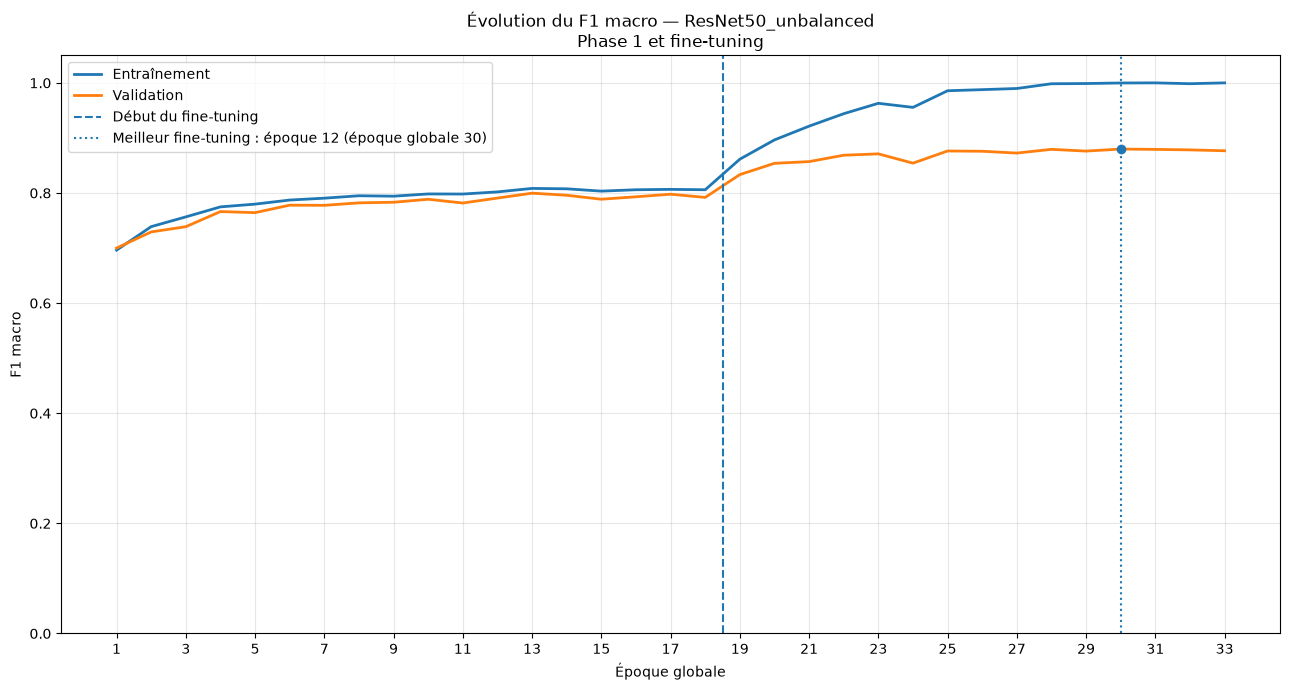

In [9]:
f1_train_combined = np.concatenate([
    history_phase1_df["f1_macro"].to_numpy(),
    history_phase2_df["f1_macro"].to_numpy()
])

f1_val_combined = np.concatenate([
    history_phase1_df["val_f1_macro"].to_numpy(),
    history_phase2_df["val_f1_macro"].to_numpy()
])

plt.figure(figsize=(13, 7))

plt.plot(
    epochs_combined,
    f1_train_combined,
    label="Entraînement",
    linewidth=2
)

plt.plot(
    epochs_combined,
    f1_val_combined,
    label="Validation",
    linewidth=2
)

plt.axvline(
    x=finetuning_start,
    linestyle="--",
    linewidth=1.5,
    label="Début du fine-tuning"
)

plt.axvline(
    x=best_epoch_phase2_global,
    linestyle=":",
    linewidth=1.5,
    label=(
        f"Meilleur fine-tuning : époque {best_epoch_phase2} "
        f"(époque globale {best_epoch_phase2_global})"
    )
)

plt.scatter(
    best_epoch_phase2_global,
    history_phase2_df.loc[
        best_epoch_phase2 - 1,
        "val_f1_macro"
    ],
    zorder=5
)

plt.title(
    "Évolution du F1 macro — ResNet50_unbalanced\n"
    "Phase 1 et fine-tuning"
)

plt.xlabel("Époque globale")
plt.ylabel("F1 macro")

plt.xticks(
    np.arange(
        1,
        n_epochs_phase1 + n_epochs_phase2 + 1,
        2
    )
)

plt.ylim(0, 1.05)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

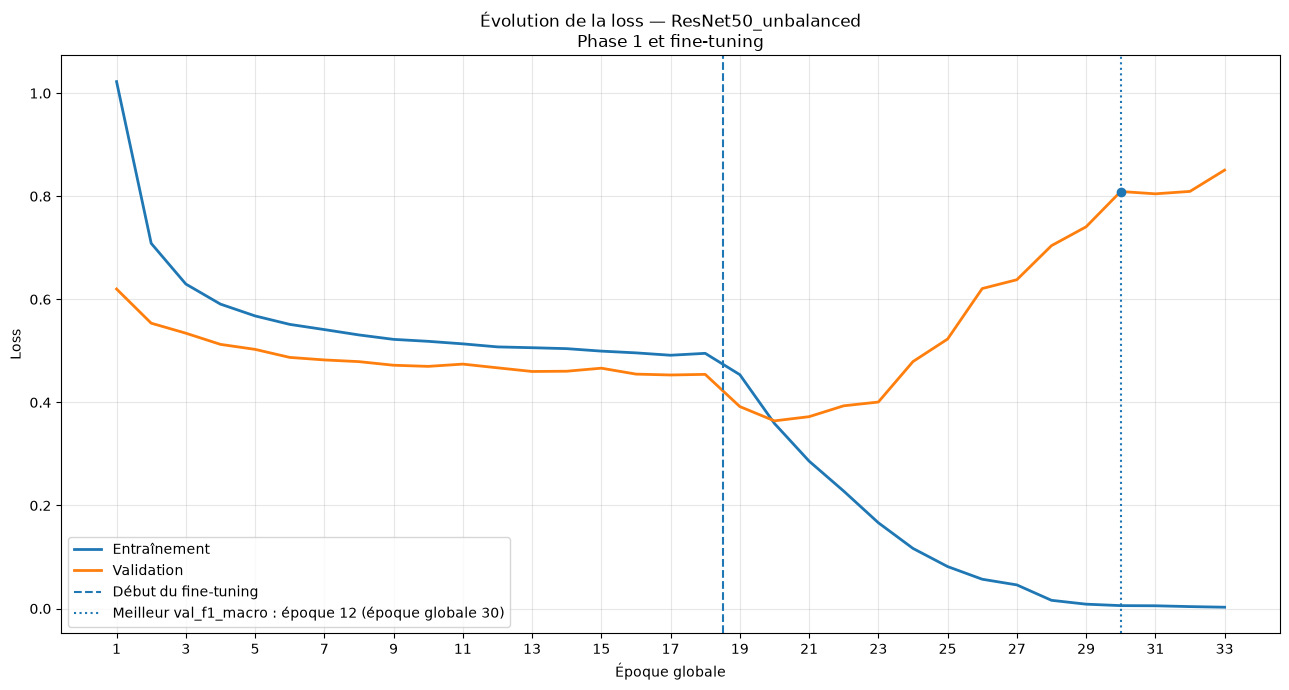

In [8]:
loss_train_combined = np.concatenate([
    history_phase1_df["loss"].to_numpy(),
    history_phase2_df["loss"].to_numpy()
])

loss_val_combined = np.concatenate([
    history_phase1_df["val_loss"].to_numpy(),
    history_phase2_df["val_loss"].to_numpy()
])

plt.figure(figsize=(13, 7))

plt.plot(
    epochs_combined,
    loss_train_combined,
    label="Entraînement",
    linewidth=2
)

plt.plot(
    epochs_combined,
    loss_val_combined,
    label="Validation",
    linewidth=2
)

plt.axvline(
    x=finetuning_start,
    linestyle="--",
    linewidth=1.5,
    label="Début du fine-tuning"
)

# Le point retenu reste celui du meilleur F1 macro de validation,
# puisque le checkpoint surveillait val_f1_macro.

plt.axvline(
    x=best_epoch_phase2_global,
    linestyle=":",
    linewidth=1.5,
    label=(
        f"Meilleur val_f1_macro : époque {best_epoch_phase2} "
        f"(époque globale {best_epoch_phase2_global})"
    )
)

plt.scatter(
    best_epoch_phase2_global,
    history_phase2_df.loc[
        best_epoch_phase2 - 1,
        "val_loss"
    ],
    zorder=5
)

plt.title(
    "Évolution de la loss — ResNet50_unbalanced\n"
    "Phase 1 et fine-tuning"
)

plt.xlabel("Époque globale")
plt.ylabel("Loss")

plt.xticks(
    np.arange(
        1,
        n_epochs_phase1 + n_epochs_phase2 + 1,
        2
    )
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Courbes Precision / Recall

In [31]:
# Import des probabilités sur la validation

y_true_val_phase2 = []
y_prob_val_phase2 = []

for images, labels in val_ds:

    probabilities = best_model_phase2.predict(
        images,
        verbose=0
    )

    y_true_val_phase2.extend(
        labels.numpy()
    )

    y_prob_val_phase2.extend(
        probabilities
    )

y_true_val_phase2 = np.array(
    y_true_val_phase2
)

y_prob_val_phase2 = np.array(
    y_prob_val_phase2
)

print(
    "Nombre d'images de validation :",
    len(y_true_val_phase2)
)

print(
    "Forme des probabilités :",
    y_prob_val_phase2.shape
)

print(
    "Ordre des classes :",
    class_names
)

I0000 00:00:1784986196.596180 3912916 service.cc:153] XLA service 0x7fc2f8064870 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1784986196.596253 3912916 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4090 Laptop GPU, Compute Capability 8.9 (Driver: 12.7.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.24.0)
I0000 00:00:1784986196.655406 3912916 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1784986197.216025 3912916 cuda_dnn.cc:461] Loaded cuDNN version 92400
I0000 00:00:1784986202.681559 3912916 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Nombre d'images de validation : 2083
Forme des probabilités : (2083, 4)
Ordre des classes : ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']


In [32]:
# Vérification de l'import

assert (
    len(y_true_val_phase2)
    == len(y_prob_val_phase2)
)

assert (
    y_prob_val_phase2.shape[1]
    == len(class_names)
)

print("Correspondance labels-prédictions validée.")

Correspondance labels-prédictions validée.


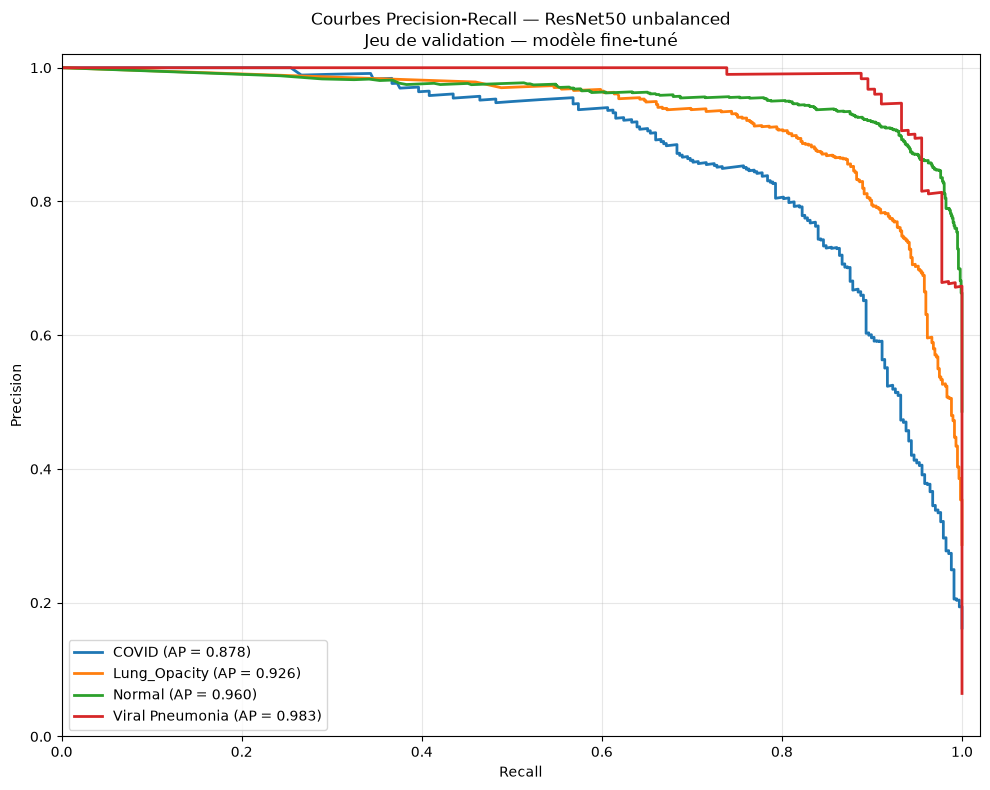

In [33]:
# Courbe Précision / Recall pour les 4 classes

from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score
)

plt.figure(figsize=(10, 8))

for class_index, class_name in enumerate(class_names):

    y_true_binary = (
        y_true_val_phase2 == class_index
    ).astype(int)

    y_score = y_prob_val_phase2[
        :,
        class_index
    ]

    precision, recall, thresholds = (
        precision_recall_curve(
            y_true_binary,
            y_score
        )
    )

    average_precision = (
        average_precision_score(
            y_true_binary,
            y_score
        )
    )

    plt.plot(
        recall,
        precision,
        linewidth=2,
        label=(
            f"{class_name} "
            f"(AP = {average_precision:.3f})"
        )
    )

plt.title(
    "Courbes Precision-Recall — ResNet50 unbalanced\n"
    "Jeu de validation — modèle fine-tuné"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.xlim(0, 1.02)
plt.ylim(0, 1.02)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Les courbes Precision-Recall confirment les bonnes performances du modèle après fine-tuning. Les meilleures AP sont obtenues pour Viral Pneumonia (0,983) et Normal (0,960), suivies de Lung_Opacity (0,926). La classe COVID reste la plus difficile (AP = 0,878), mais les performances sont très proches de celles obtenues avec les class weights.

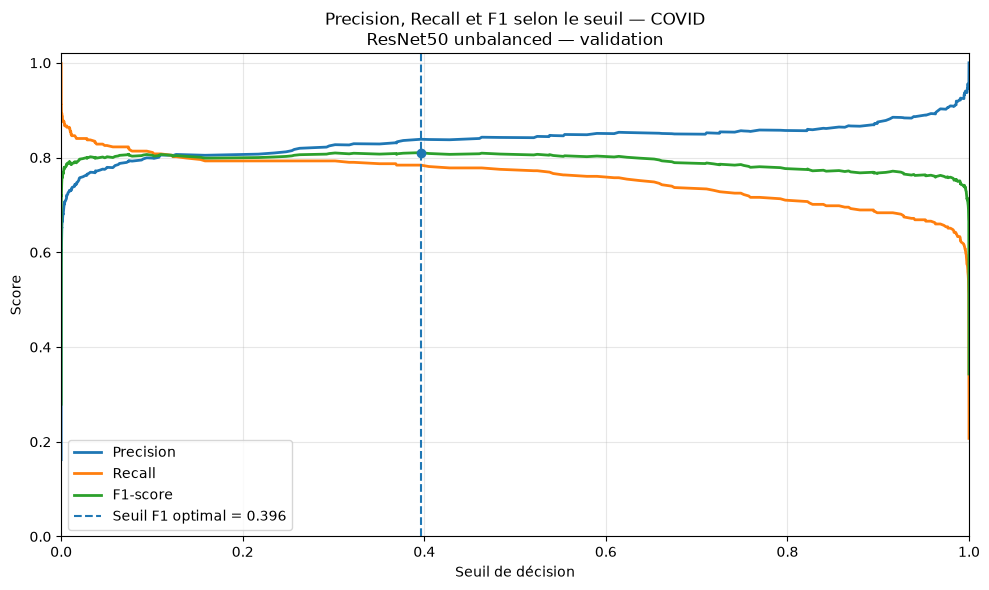

Classe : COVID
Seuil optimal : 0.3962
Precision : 0.8386
Recall : 0.7840
F1-score : 0.8104
--------------------------------------------------


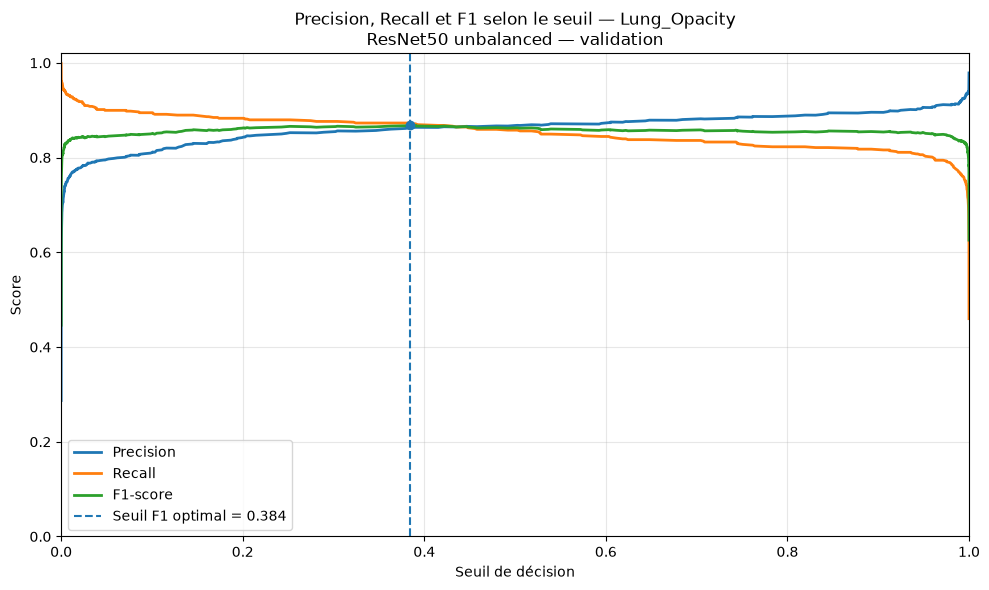

Classe : Lung_Opacity
Seuil optimal : 0.3841
Precision : 0.8628
Recall : 0.8729
F1-score : 0.8678
--------------------------------------------------


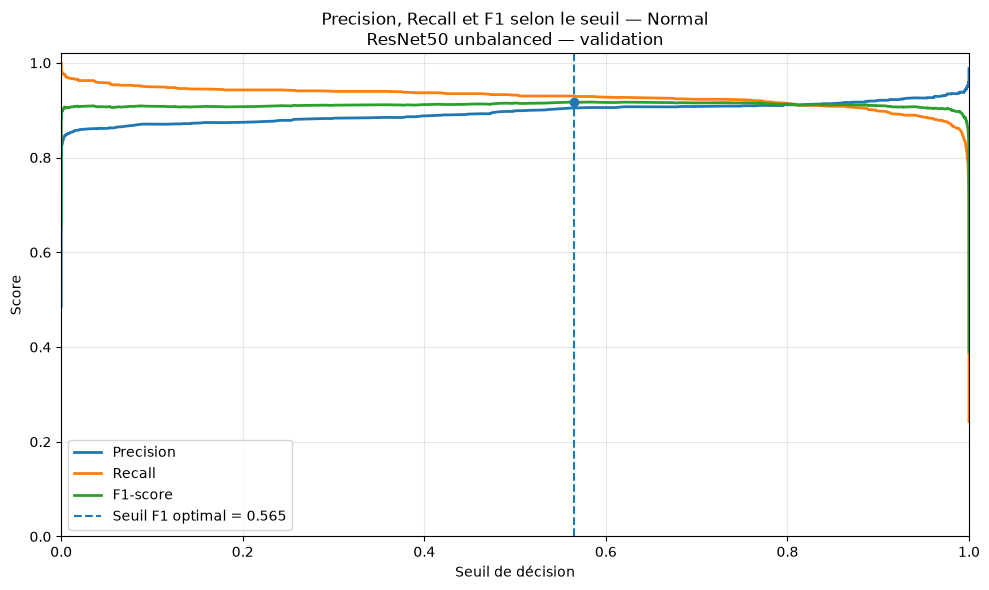

Classe : Normal
Seuil optimal : 0.5649
Precision : 0.9049
Recall : 0.9299
F1-score : 0.9172
--------------------------------------------------


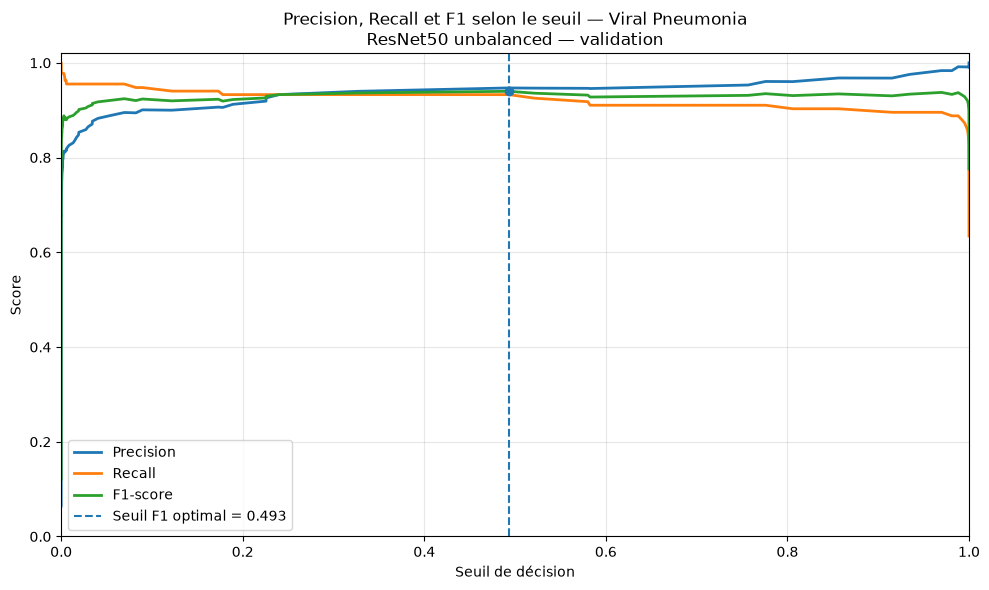

Classe : Viral Pneumonia
Seuil optimal : 0.4932
Precision : 0.9470
Recall : 0.9328
F1-score : 0.9398
--------------------------------------------------


In [34]:
# Courbe Précision / Recall selon le seuil pour les 4 classes

for class_index, class_name in enumerate(class_names):

    y_true_binary = (
        y_true_val_phase2 == class_index
    ).astype(int)

    y_score = y_prob_val_phase2[
        :,
        class_index
    ]

    precision, recall, thresholds = (
        precision_recall_curve(
            y_true_binary,
            y_score
        )
    )

    # precision et recall ont une valeur de plus
    # que le tableau thresholds
    precision_by_threshold = precision[:-1]
    recall_by_threshold = recall[:-1]

    f1_by_threshold = (
        2
        * precision_by_threshold
        * recall_by_threshold
        / (
            precision_by_threshold
            + recall_by_threshold
            + 1e-12
        )
    )

    best_index = np.argmax(
        f1_by_threshold
    )

    best_threshold = thresholds[
        best_index
    ]

    best_precision = precision_by_threshold[
        best_index
    ]

    best_recall = recall_by_threshold[
        best_index
    ]

    best_f1 = f1_by_threshold[
        best_index
    ]

    plt.figure(figsize=(10, 6))

    plt.plot(
        thresholds,
        precision_by_threshold,
        label="Precision",
        linewidth=2
    )

    plt.plot(
        thresholds,
        recall_by_threshold,
        label="Recall",
        linewidth=2
    )

    plt.plot(
        thresholds,
        f1_by_threshold,
        label="F1-score",
        linewidth=2
    )

    plt.axvline(
        best_threshold,
        linestyle="--",
        label=(
            f"Seuil F1 optimal = "
            f"{best_threshold:.3f}"
        )
    )

    plt.scatter(
        best_threshold,
        best_f1,
        zorder=5
    )

    plt.title(
        f"Precision, Recall et F1 selon le seuil — {class_name}\n"
        "ResNet50 unbalanced — validation"
    )

    plt.xlabel("Seuil de décision")
    plt.ylabel("Score")

    plt.xlim(0, 1)
    plt.ylim(0, 1.02)

    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"Classe : {class_name}")
    print(
        f"Seuil optimal : "
        f"{best_threshold:.4f}"
    )
    print(
        f"Precision : "
        f"{best_precision:.4f}"
    )
    print(
        f"Recall : "
        f"{best_recall:.4f}"
    )
    print(
        f"F1-score : "
        f"{best_f1:.4f}"
    )
    print("-" * 50)

Le seuil optimal pour la classe COVID est de 0,396, permettant d'obtenir un bon compromis entre précision (0,839) et rappel (0,784), avec un F1-score de 0,810. Ce seuil est légèrement inférieur à 0,5 afin de mieux détecter les cas COVID sans dégrader excessivement la précision.